# 1. 데이터 불러오기 및 전처리

- pandas로 데이터 셋 로드
- data info 확인
- date 기준으로 내림 차순 정렬 

In [70]:
#pandas로 데이터 셋 로드 

import pandas as pd 
from IPython.display import display

df = pd.read_csv('../../data/crawled_data.csv')
df.info()

# 시계열 분석하기 위해 date의 dtype을 datetime 형식으로 바꾸기 
df['date'] = pd.to_datetime(df['date'])

# date 기준으로 내림차순 정렬
df_sorted = df.sort_values(by='date', ascending=False)


# 최신 뉴스
print("최신 뉴스 5개")
display(df_sorted[['date', 'title']].head())

# 오래된 뉴스
print("오래된 뉴스 5개")
display(df_sorted[['date', 'title']].tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18558 entries, 0 to 18557
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   18558 non-null  object
 1   link    18558 non-null  object
 2   author  18558 non-null  object
 3   date    18558 non-null  object
 4   body    18558 non-null  object
dtypes: object(5)
memory usage: 725.1+ KB
최신 뉴스 5개


,date,title
0,2025-06-05,"허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시"
13,2025-06-05,AI빅데이터쇼 아크릴 AI 플랫폼으로 헬스케어 혁신
1,2025-06-05,"레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소"
23,2025-06-05,6월4일 기업 비용 절감을 위한 AI 활용의 새로운 사례...노후 소프트웨어 현대화
22,2025-06-05,AI의 역사 41 추론 중 결국 멈춰서 버린 로봇 프레임 문제와 다니엘 데닛


오래된 뉴스 5개


,date,title
18553,2020-01-02,"구글AI, 사람 의사보다 유방암 진단 정확도 높다"
18554,2020-01-02,2020년 AI혁명 우리의 삶이 완전히 바뀐다 AI타임스 신년시리즈
18555,2020-01-02,AI가 차량 소리 감지해 헤드폰에 경보 울린다
18556,2020-01-01,경자년 새해 맞이 보성 율포해변 불꽃축제
18557,2020-01-01,포토 케이스 Case IH의 자율주행 트랙터


## 📌 현재 수집한 뉴스 데이터는 2020-01-01~ 2025-06-05까지의 18558개의 데이터 
---

## 1) 제목, 날짜, 본문 컬럼만 남기기 

In [71]:
# 제목, 날짜, 본문 컬럼만 남기기 
df = df[['title','date','body']]
df.head()

,title,date,body
0,"허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시",2025-06-05,허깅페이스가 범용 로봇 에이전트 개발을 위한 오픈소스 비전언어행동 VLA 모델을 선...
1,"레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소",2025-06-05,소셜 미디어 플랫폼 레딧이 앤트로픽을 상대로 동의 없이 게시물을 수집해 인공지능 A...
2,"미스트랄, 코딩 AI 역량 총 집결한 기업용 어시스턴트 미스트랄 코드 출시",2025-06-05,미스트랄 AI가 기업을 위한 인공지능 AI 코딩 어시스턴트를 공개했다. 이번 출시는...
3,"오픈AI, 업무용 AI 도구 대거 출시...MS구글과 에이전트 경쟁 불가피",2025-06-05,오픈AI가 마이크로소프트 MS 나 구글의 기업용 인공지능 AI 제품을 겨냥한 업무용...
4,미중 갈등으로 애플 인텔리전스 중국 출시 지연,2025-06-05,알리바바와의 협력으로 중국에서 아이폰용 인공지능 AI 서비스를 출시하려는 애플의 계...


---
# 2. 형태소 분석[뉴스 제목] 

## 뉴스 제목 데이터를 바탕으로 키워드를 분석하기. 
- 키워드 트렌드 파악하기
- (추출한 키워드 바탕으로 기술 키워드 만들기)
- 제목 컬럼명 : `title`


In [72]:
df.head()

,title,date,body
0,"허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시",2025-06-05,허깅페이스가 범용 로봇 에이전트 개발을 위한 오픈소스 비전언어행동 VLA 모델을 선...
1,"레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소",2025-06-05,소셜 미디어 플랫폼 레딧이 앤트로픽을 상대로 동의 없이 게시물을 수집해 인공지능 A...
2,"미스트랄, 코딩 AI 역량 총 집결한 기업용 어시스턴트 미스트랄 코드 출시",2025-06-05,미스트랄 AI가 기업을 위한 인공지능 AI 코딩 어시스턴트를 공개했다. 이번 출시는...
3,"오픈AI, 업무용 AI 도구 대거 출시...MS구글과 에이전트 경쟁 불가피",2025-06-05,오픈AI가 마이크로소프트 MS 나 구글의 기업용 인공지능 AI 제품을 겨냥한 업무용...
4,미중 갈등으로 애플 인텔리전스 중국 출시 지연,2025-06-05,알리바바와의 협력으로 중국에서 아이폰용 인공지능 AI 서비스를 출시하려는 애플의 계...


In [73]:
## 날짜 컬럼 데이터 타입 변경
df['date'] = pd.to_datetime(df['date'])

## 뉴스 제목 추출
titles = df['title']

print(titles)

0                허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시
1                   레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소
2        미스트랄, 코딩 AI 역량 총 집결한 기업용 어시스턴트 미스트랄 코드 출시
3        오픈AI, 업무용 AI 도구 대거 출시...MS구글과 에이전트 경쟁 불가피
4                        미중 갈등으로 애플 인텔리전스 중국 출시 지연
                           ...                    
18553                  구글AI, 사람 의사보다 유방암 진단 정확도 높다
18554       2020년 AI혁명 우리의 삶이 완전히 바뀐다  AI타임스 신년시리즈
18555                    AI가 차량 소리 감지해 헤드폰에 경보 울린다
18556                       경자년 새해 맞이 보성 율포해변 불꽃축제
18557                     포토 케이스 Case IH의 자율주행 트랙터
Name: title, Length: 18558, dtype: object


### 2-1)형태소 분석  

In [98]:
import sys
sys.path.append('../../') #상위 폴더 접근 

from analysis.preprocess_module import preprocess_text, remove_stopwords

title_tokens = titles.apply(preprocess_text)

# 형태소 분석기 이용해서 분석하고, 글자 길이가 1 이하인것들 추출해서 불용어 리스트 만들기 

In [99]:
print(title_tokens[:5]) 

0    [허깅, 페이스, 맥북, 에서, 구동, 하는, 로봇, 용, 시각언어, 행동, 모델,...
1           [레딧, 무단, 으로, ai, 훈련, 데이터, 사용, 한, 앤트로픽, 고소]
2    [미스트랄, 코딩, ai, 역량, 총, 집결, 한, 기업, 용, 어시스턴트, 미스트...
3    [오픈, ai, 업무, 용, ai, 도구, 대거, 출시, ms, 구글, 과, 에이전...
4                [미, 중, 갈등, 으로, 애플, 인텔리전스, 중국, 출시, 지연]
Name: title, dtype: object


In [100]:
# 불용어 추출
from konlpy.tag import Okt
from collections import Counter


okt = Okt()
#뉴스 제목 전체에서 명사만 추출
all_nouns = []
for text in df['title'].fillna(''):
    nouns = okt.nouns(text)
    all_nouns.extend(nouns)

nouns_counter = Counter(all_nouns)

print(nouns_counter)

Counter({'출시': 1633, '기술': 1392, '생': 1265, '공개': 1219, '오픈': 1214, '개발': 1131, '기업': 1074, '데이터': 970, '구글': 860, '모델': 853, '서비스': 841, '것': 761, '솔루션': 750, '로봇': 699, '로': 682, '메타': 672, '위': 661, '투자': 611, '플랫폼': 587, '용': 583, '챗': 570, '딥': 566, '사업': 555, '지원': 547, '지능': 528, '등': 528, '미국': 503, '개최': 490, '구축': 489, '중국': 487, '기반': 476, '스타트업': 462, '글로벌': 459, '클라우드': 457, '선정': 442, '엔비디아': 433, '등장': 415, '도입': 414, '활용': 412, '챗봇': 412, '인공': 404, '국내': 396, '디지털': 382, '삼성': 373, '버스': 373, '애플': 359, '검색': 354, '교육': 351, '자율': 351, '협력': 350, '에이전트': 343, '시장': 332, '태양광': 332, '기능': 330, '발표': 327, '네이버': 327, '칩': 324, '학습': 313, '공급': 310, '혁신': 309, '세계': 309, '중': 302, '시스템': 300, '위해': 299, '첫': 298, '대표': 294, '산업': 292, '이미지': 292, '확대': 287, '강화': 286, '앱': 282, '테크': 281, '연구': 278, '분석': 276, '에이': 269, '영상': 269, '개': 268, '수상': 266, '센터': 265, '한국': 265, '사용': 256, '정부': 256, '제공': 253, '아이': 251, '전자': 250, '스마트': 247, '추가': 246, '달': 246, '반도체': 245,

In [77]:
# 불용어 리스트
stopwords = [] 

for word, count in nouns_counter.most_common(1000):
    # 길이가 짧은 조사(은, 는, 이, 가 등)와 불용어 추출
    if len(word) < 2:
        stopwords.append(word) 

print(stopwords)


#길이가 짧은 단어 추출 후, 해당 단어가 포함된 뉴스 제목 불러와 의미가 있는 단어인지 확인해보기. 
count = 0

for title in df['title'].fillna(''):
   nouns = okt.nouns(title)
   if '이' in nouns:
    print(title)
    count += 1
    if count == 10:
       break

['생', '것', '로', '위', '용', '챗', '딥', '등', '칩', '중', '첫', '앱', '개', '달', '의', '배', '랩', '과', '쇼', '수', '초', '팀', '더', '전', '및', '주', '바', '법', '업', '스', '새', '곳', '코', '명', '기', '내', '빅', '제', '입', '인', '웹', '알', '리', '를', '안', '뉴', '트', '헬', '비', '처', '말', '젠', '티', '브', '유', '황', '투', '도', '종', '사', '토', '디', '얼', '회', '베', '연', '뇌', '온', '셋', '닷', '렉', '링', '차', '터', '앤', '뒤', '피', '큐', '임', '속', '톤', '못', '건', '이', '손', '모', '션', '또', '카', '론', '점', '간', '세', '포', '후', '일', '단', '최', '계', '편', '관', '시', '키', '썸', '컴', '재', '셀', '톱', '물', '년', '선', '봇', '창', '솔', '나', '톡', '총', '웰', '액', '뷰', '줌', '듯', '별', '노', '책', '킹', '씨', '캣', '소', '급', '존', '빙', '날', '게', '돈', '델', '어', '부', '펫']
iOS 18이 iOS 26으로 변경...애플, OS 버전 표시 연도로 교체
LLM이 사용자 정보 알고 있으면 설득 확률 급상승...인터넷 노출 정보만으로 충분
4월22일 AI로 인해 57년 내 상시 접속형 경제 본격화...기업은 이에 발맞춰야
이든티앤에스, AX 서밋서 에이전틱AI 기반 인사 검증 자동화 사례 공개
추론 모델, 벤치마크 비용도 2배 들어...o1이 가장 비싸
RAG 필요 없이 LLM이 자율 검색하는 추론 기술 등장
LLM이 실제 SW 작업으로 돈을 벌 수 있을까...오픈AI, 실험 결과 공개
추론 능력은 o1이 앞서지만, 

In [150]:
# 수정한 불용어 리스트 + 한국어 불용어 리스트 예시 참고 
stopwords = ['것', '위하', '용','등', '의', '과', '수', '더','및', '을','를','에','가','그렇', '없', '하는', '도',
             '으로','로','에게','그리고','또는','하지만','때문에','그래서','으로', '은','는','이','한','서','와','위']
print(stopwords)




['것', '위하', '용', '등', '의', '과', '수', '더', '및', '을', '를', '에', '가', '그렇', '없', '하는', '도', '으로', '로', '에게', '그리고', '또는', '하지만', '때문에', '그래서', '으로', '은', '는', '이', '한', '서', '와', '위']


### 2-2)조사먼저 제거 -> 불용어제거 
('이' 와 같은 조사를 처리하기 위해서) 


In [181]:
from konlpy.tag import Okt
okt = Okt()

# '이'가 조사(Josa)일 때만 제거할 리스트 만들기
def remove_josa(token_list):
    result = []
    for token in token_list:
        # 각 단어 단위로 품사 확인
        for word, pos in okt.pos(token):
            if pos != 'Josa': #조사 아닌 것만 남김
                result.append(word)
    return result

title_tokens_no_josa = title_tokens.apply(remove_josa)

---
조사제거 확인 


In [182]:
for i in range(5):  # 앞에서 5개만 예시 확인
    print(f"\n🔹 [{i+1}번째 뉴스 제목]")
    print("조사 제거 전:", title_tokens.iloc[i])
    print("조사 제거 후:", title_tokens_no_josa.iloc[i])
    print("-" * 50)



🔹 [1번째 뉴스 제목]
조사 제거 전: ['허깅', '페이스', '맥북', '에서', '구동', '하는', '로봇', '용', '시각언어', '행동', '모델', '출시']
조사 제거 후: ['허깅', '페이스', '맥북', '구동', '하는', '로봇', '용', '시각언어', '행동', '모델', '출시']
--------------------------------------------------

🔹 [2번째 뉴스 제목]
조사 제거 전: ['레딧', '무단', '으로', 'ai', '훈련', '데이터', '사용', '한', '앤트로픽', '고소']
조사 제거 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '한', '앤트로픽', '고소']
--------------------------------------------------

🔹 [3번째 뉴스 제목]
조사 제거 전: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '한', '기업', '용', '어시스턴트', '미스트랄', '코드', '출시']
조사 제거 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '한', '기업', '용', '어시스턴트', '미스트랄', '코드', '출시']
--------------------------------------------------

🔹 [4번째 뉴스 제목]
조사 제거 전: ['오픈', 'ai', '업무', '용', 'ai', '도구', '대거', '출시', 'ms', '구글', '과', '에이전트', '경쟁', '불가피']
조사 제거 후: ['오픈', 'ai', '업무', '용', 'ai', '도구', '대거', '출시', 'ms', '구글', '과', '에이전트', '경쟁', '불가피']
--------------------------------------------------

🔹 [5번째 뉴스 제목]
조사 제거 전: ['미', '중', '갈등', '으로', '애플', '인텔리전스', 

In [184]:
# 불용어 제거 전, 후 확인
#불용어 제거 
clean_title_tokens = title_tokens_no_josa.apply(lambda tokens: remove_stopwords(tokens, stopwords))

                                           
for i in range(5):  
    print(f"\n🔹 [{i+1}번째]")
    print("조사 제거후 불용어 제거 전:", title_tokens_no_josa.iloc[i][:20])   # 너무 길 경우 앞 20개만 표시
    print("불용어 제거 후:", clean_title_tokens.iloc[i][:20])
    print("-" * 50)


🔹 [1번째]
조사 제거후 불용어 제거 전: ['허깅', '페이스', '맥북', '구동', '하는', '로봇', '용', '시각언어', '행동', '모델', '출시']
불용어 제거 후: ['허깅', '페이스', '맥북', '구동', '로봇', '시각언어', '행동', '모델', '출시']
--------------------------------------------------

🔹 [2번째]
조사 제거후 불용어 제거 전: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '한', '앤트로픽', '고소']
불용어 제거 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '앤트로픽', '고소']
--------------------------------------------------

🔹 [3번째]
조사 제거후 불용어 제거 전: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '한', '기업', '용', '어시스턴트', '미스트랄', '코드', '출시']
불용어 제거 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '기업', '어시스턴트', '미스트랄', '코드', '출시']
--------------------------------------------------

🔹 [4번째]
조사 제거후 불용어 제거 전: ['오픈', 'ai', '업무', '용', 'ai', '도구', '대거', '출시', 'ms', '구글', '과', '에이전트', '경쟁', '불가피']
불용어 제거 후: ['오픈', 'ai', '업무', 'ai', '도구', '대거', '출시', 'ms', '구글', '에이전트', '경쟁', '불가피']
--------------------------------------------------

🔹 [5번째]
조사 제거후 불용어 제거 전: ['미', '중', '갈등', '애플', '인텔리전스', '중국', '출시', '지연']
불용어 제거 후: ['미', '중', '

### 2-3) 병합 함수, 병합 키워드 만들기
- 불용어 제거 후 상위 20개 키워드 추출한 결과 -> 생/성 등 단어가 분리되는 현상 있음 

In [185]:
# 불용어 제거 후 상위 20개 키워드 분석 -> 생/성 분리되는 현상 있음 
#병합 키워드를 만들어 보완하기

#키워드 병합 함수 
def merge_keywords(tokens, merge_dict):
    merged = [] #병합된 결과를 반환할 리스트 
    i = 0 # 토큰 리스트의 현재 위치 인덱스 
    while i < len(tokens):
        found = False
        for length in [3, 2]:  # 3단어 조합 우선 → 2단어 조합
            group = tuple(tokens[i:i+length])
            if group in merge_dict:
                merged.append(merge_dict[group])
                i += length
                found = True
                break
        if not found:
            merged.append(tokens[i])
            i += 1
    return merged


# 병합 딕셔너리 정의
merge_dict = {
    ('인공', '지능'): '인공지능',
    ('오픈', 'ai'): '오픈ai',
    ('생', '성'): '생성',
    ('허깅', '페이스'): '허깅페이스',
    ('챗', 'gpt'): '챗gpt',
    ('chat', 'gpt'): '챗gpt',
    ('양자', '컴퓨터'): '양자컴퓨팅',
    ('양자', '컴퓨팅'): '양자컴퓨팅',
    ('자연어', '처리'): 'nlp',
    ('이미지', '처리'): '이미지처리',
    ('대형','언어', '모델'): '대형언어모델',
    ('바이브','코딩'): '바이브코딩',
    ######### 병합 단어 추가 
    #딥시크
    ('딥','시크') : '딥시크',
    ('deep', 'sik'): '딥시크',

    #딥페이크
    ('딥', '페이크') : '딥페이크',
    ('deep', 'fake'): '딥페이크',

    #딥러닝
    ('딥', '러닝') : '딥러닝',
    ('deep', 'learning'): '딥러닝',

    #딥브레인
    ('딥','브레인') : '딥브레인',
    ('deep', 'brain'): '딥브레인',

     # 딥마인드
    ('딥', '마인드'): '딥마인드',
    ('deep', 'mind'): '딥마인드',

    # 딥엑스
    ('딥', '엑스'): '딥엑스',
    ('deep', 'x'): '딥엑스',

    # 딥엘 (AI 번역기 DeepL)
    ('딥', '엘'): '딥엘',
    ('deep', 'l'): '딥엘',  # DeepL 표기

    # 딥리서치
    ('딥', '리서치'): '딥리서치',
    ('deep', 'research'): '딥리서치',

    # 딥파인
    ('딥', '파인'): '딥파인',
    ('deep', 'fine'): '딥파인',  # 의미상 추정

    # 딥인사이트
    ('딥', '인사이트'): '딥인사이트',
    ('deep', 'insight'): '딥인사이트',


}


# 병합 함수 적용
merged_tokens = clean_title_tokens.apply(lambda tokens: merge_keywords(tokens, merge_dict))

# 병합 결과 확인
for i in range(5):
    print(f"\n🔹 [{i+1}번째 뉴스]")
    print("병합 전:", clean_title_tokens.iloc[i])
    print("병합 후:", merged_tokens.iloc[i])
    print("-" * 50)



🔹 [1번째 뉴스]
병합 전: ['허깅', '페이스', '맥북', '구동', '로봇', '시각언어', '행동', '모델', '출시']
병합 후: ['허깅페이스', '맥북', '구동', '로봇', '시각언어', '행동', '모델', '출시']
--------------------------------------------------

🔹 [2번째 뉴스]
병합 전: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '앤트로픽', '고소']
병합 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '앤트로픽', '고소']
--------------------------------------------------

🔹 [3번째 뉴스]
병합 전: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '기업', '어시스턴트', '미스트랄', '코드', '출시']
병합 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '기업', '어시스턴트', '미스트랄', '코드', '출시']
--------------------------------------------------

🔹 [4번째 뉴스]
병합 전: ['오픈', 'ai', '업무', 'ai', '도구', '대거', '출시', 'ms', '구글', '에이전트', '경쟁', '불가피']
병합 후: ['오픈ai', '업무', 'ai', '도구', '대거', '출시', 'ms', '구글', '에이전트', '경쟁', '불가피']
--------------------------------------------------

🔹 [5번째 뉴스]
병합 전: ['미', '중', '갈등', '애플', '인텔리전스', '중국', '출시', '지연']
병합 후: ['미', '중', '갈등', '애플', '인텔리전스', '중국', '출시', '지연']
--------------------------------------------------


In [186]:
merged_tokens.head(5)

0                [허깅페이스, 맥북, 구동, 로봇, 시각언어, 행동, 모델, 출시]
1                  [레딧, 무단, ai, 훈련, 데이터, 사용, 앤트로픽, 고소]
2    [미스트랄, 코딩, ai, 역량, 총, 집결, 기업, 어시스턴트, 미스트랄, 코드,...
3    [오픈ai, 업무, ai, 도구, 대거, 출시, ms, 구글, 에이전트, 경쟁, 불가피]
4                    [미, 중, 갈등, 애플, 인텔리전스, 중국, 출시, 지연]
Name: title, dtype: object

In [187]:
for i in range(10):
    print(f"\n🔹[{i+1}번째]")
    print("조사 제거 후:", title_tokens_no_josa.iloc[i])
    print("불용어 제거 후:", clean_title_tokens.iloc[i])
    print("병합 후:", merged_tokens.iloc[i])



🔹[1번째]
조사 제거 후: ['허깅', '페이스', '맥북', '구동', '하는', '로봇', '용', '시각언어', '행동', '모델', '출시']
불용어 제거 후: ['허깅', '페이스', '맥북', '구동', '로봇', '시각언어', '행동', '모델', '출시']
병합 후: ['허깅페이스', '맥북', '구동', '로봇', '시각언어', '행동', '모델', '출시']

🔹[2번째]
조사 제거 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '한', '앤트로픽', '고소']
불용어 제거 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '앤트로픽', '고소']
병합 후: ['레딧', '무단', 'ai', '훈련', '데이터', '사용', '앤트로픽', '고소']

🔹[3번째]
조사 제거 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '한', '기업', '용', '어시스턴트', '미스트랄', '코드', '출시']
불용어 제거 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '기업', '어시스턴트', '미스트랄', '코드', '출시']
병합 후: ['미스트랄', '코딩', 'ai', '역량', '총', '집결', '기업', '어시스턴트', '미스트랄', '코드', '출시']

🔹[4번째]
조사 제거 후: ['오픈', 'ai', '업무', '용', 'ai', '도구', '대거', '출시', 'ms', '구글', '과', '에이전트', '경쟁', '불가피']
불용어 제거 후: ['오픈', 'ai', '업무', 'ai', '도구', '대거', '출시', 'ms', '구글', '에이전트', '경쟁', '불가피']
병합 후: ['오픈ai', '업무', 'ai', '도구', '대거', '출시', 'ms', '구글', '에이전트', '경쟁', '불가피']

🔹[5번째]
조사 제거 후: ['미', '중', '갈등', '애플', '인텔리전스', '중국', '출시', '지

## 3. 키워드 분석

In [188]:
from itertools import chain

#여러 리스트를 하나로 연결하는 평탄화 작업
all_title_tokens = list(chain.from_iterable(merged_tokens))

token_freq = Counter(all_title_tokens)

#상위 20개 단어 출력 

print("뉴스 제목 상위 20개 단어")
for word, cnt in token_freq.most_common(20):
    print(f"{word} : {cnt}")

# 제목 상위 20개 단어 출력했더니, 한/서/이/와/는 > 과 같은 단어 출력 

뉴스 제목 상위 20개 단어
ai : 9980
출시 : 1628
기술 : 1391
공개 : 1211
생성 : 1148
개발 : 1130
기업 : 1071
데이터 : 970
구글 : 857
모델 : 844
서비스 : 841
오픈ai : 812
솔루션 : 750
로봇 : 699
메타 : 673
3 : 622
투자 : 611
플랫폼 : 587
사업 : 555
ms : 548


---

### 상위 키워드 추출시 '딥' 단어가 추출됨 
### '딥'은 복합 단어의 일부. '딥' 다음에 어떤 단어가 자주 나오는지 파악하여 병합 후보 찾기 -> 찾은 후 merge_dict 에 추가 (2-3)

In [189]:
# '딥' 에 어떤 단어가 자주 나오는지 확인하기 

from nltk import ngrams
from collections import Counter
from itertools import chain

# 모든 토큰 flatten
tokens_flat = list(chain.from_iterable(merged_tokens))  # or clean_title_tokens

# bi-gram 만들기
bigrams = list(ngrams(tokens_flat, 2))

# '딥'으로 시작하는 조합만 보기
deep_bigrams = [pair for pair in bigrams if pair[0] == '딥']

# 빈도순 확인
deep_bigram_counts = Counter(deep_bigrams)
print(deep_bigram_counts.most_common(10))


[(('딥', '테크'), 10), (('딥', '서치'), 8), (('딥', '보이스'), 2), (('딥', '오토'), 2), (('딥', '플랜'), 2), (('딥', '카스'), 2), (('딥', '싱크'), 1), (('딥', 'ocr'), 1), (('딥', '오픈'), 1), (('딥', '헤르메스'), 1)]


---

## 4. 시각화 

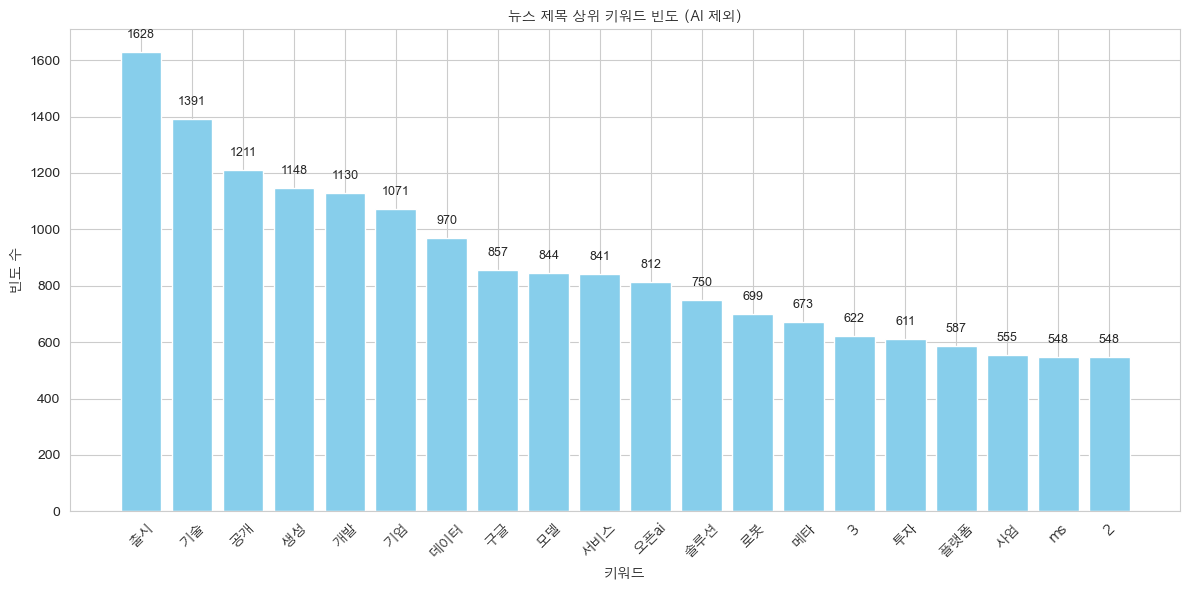

In [191]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_name
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 상위 20개에서 ai 제거
top_keywords = token_freq.most_common(21)[1:]
words, counts = zip(*top_keywords)

# 스타일
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
bars = plt.bar(words, counts, color='skyblue')

# 수치 라벨 추가
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, int(yval), ha='center', fontsize=9)
    fontproperties=font_prop 

plt.title("뉴스 제목 상위 키워드 빈도 (AI 제외)",fontproperties=font_prop )
plt.xlabel("키워드",fontproperties=font_prop )
plt.ylabel("빈도 수",fontproperties=font_prop )
plt.xticks(rotation=45,fontproperties=font_prop )
plt.tight_layout()
plt.show()



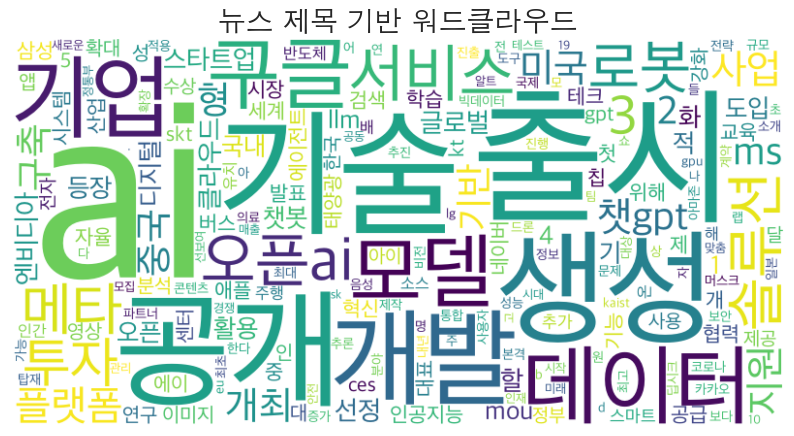

In [192]:
from wordcloud import WordCloud
import platform

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS인 경우
# plt.rcParams['font.family'] = 'NanumGothic'  # 설치했을 때
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

############

if platform.system() == 'Windows':
    font_path = 'NanumFothic.ttf'
elif platform.system() == 'Darwin': #macOS
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else: #Assume Colab or Linux
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'


# 워드클라우드 생성
wc = WordCloud(
   font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(dict(token_freq.most_common(200)))

# 3. 시각화
plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("뉴스 제목 기반 워드클라우드", fontsize=20)
plt.show()

---
## 5. 시계열 분석 
### 특정 키워드가 월별로 얼마나 언급 됐는지 시계열 분석하고 그 결과를 시각화한다.
- (날짜 + 키워드)

In [193]:
print(merged_tokens.head(5))

0                [허깅페이스, 맥북, 구동, 로봇, 시각언어, 행동, 모델, 출시]
1                  [레딧, 무단, ai, 훈련, 데이터, 사용, 앤트로픽, 고소]
2    [미스트랄, 코딩, ai, 역량, 총, 집결, 기업, 어시스턴트, 미스트랄, 코드,...
3    [오픈ai, 업무, ai, 도구, 대거, 출시, ms, 구글, 에이전트, 경쟁, 불가피]
4                    [미, 중, 갈등, 애플, 인텔리전스, 중국, 출시, 지연]
Name: title, dtype: object


In [ ]:
from itertools import chain
import pandas as pd

# 1. 날짜 + 토큰 리스트를 연결
token_date_pairs = []

for date, tokens in zip(df['date'], merged_tokens):
    for token in tokens:
        token_date_pairs.append((date, token))

# 2. 데이터프레임 생성
dated_keyword_df = pd.DataFrame(token_date_pairs, columns=['date', 'token'])

print(dated_keyword_df.head())



        date  token
0 2025-06-05  허깅페이스
1 2025-06-05     맥북
2 2025-06-05     구동
3 2025-06-05     로봇
4 2025-06-05   시각언어


In [196]:
dated_keyword_df.dtypes

date     datetime64[ns]
token            object
dtype: object

In [ ]:
# 3. 날짜를 월 단위로 변환/dt.to_period('M') : 연,월 단위만 추출
dated_keyword_df['month'] = pd.to_datetime(dated_keyword_df['date']).dt.to_period('M')
dated_keyword_df.head()

,date,token,month
0,2025-06-05,허깅페이스,2025-06
1,2025-06-05,맥북,2025-06
2,2025-06-05,구동,2025-06
3,2025-06-05,로봇,2025-06
4,2025-06-05,시각언어,2025-06


In [199]:
dated_keyword_df['week'] = pd.to_datetime(dated_keyword_df['date']).dt.to_period('W')
dated_keyword_df.head()

,date,token,month,week
0,2025-06-05,허깅페이스,2025-06,2025-06-02/2025-06-08
1,2025-06-05,맥북,2025-06,2025-06-02/2025-06-08
2,2025-06-05,구동,2025-06,2025-06-02/2025-06-08
3,2025-06-05,로봇,2025-06,2025-06-02/2025-06-08
4,2025-06-05,시각언어,2025-06,2025-06-02/2025-06-08


In [205]:
monthly_keyword_count = (
    dated_keyword_df
    .groupby(['month', 'token'])
    .size()
    .reset_index(name='count')
)


In [242]:
top_by_month = (
    monthly_keyword_count
    .sort_values(['month', 'count'], ascending=[True, False])  # 월별로 정렬
    .groupby('month')
    .head(30)  # 각 월별 상위 10개
)

##워드클라우드 생성시 상위 키워드 개수 조절해서 만들기 

In [243]:
# 특정 월만 필터링
top_2025={
'jan25_top' : top_by_month[top_by_month['month'] == '2025-01'],
'feb25_top' : top_by_month[top_by_month['month'] == '2025-02'],
'mar25_top' : top_by_month[top_by_month['month'] == '2025-03'],
'apr25_top' : top_by_month[top_by_month['month'] == '2025-04'],
'may25_top' : top_by_month[top_by_month['month'] == '2025-05'],
}

top_2024 = {

'jan24_top' : top_by_month[top_by_month['month'] == '2024-01'],
'feb24_top' : top_by_month[top_by_month['month'] == '2024-02'],
'mar24_top' : top_by_month[top_by_month['month'] == '2024-03'],
'apr24_top' : top_by_month[top_by_month['month'] == '2024-04'],
'may24_top' : top_by_month[top_by_month['month'] == '2024-05'],
'jun24_top' : top_by_month[top_by_month['month'] == '2024-06'],
'jul24_top' : top_by_month[top_by_month['month'] == '2024-07'],
'aug24_top' : top_by_month[top_by_month['month'] == '2024-08'],
'sep24_top' : top_by_month[top_by_month['month'] == '2024-09'],
'oct24_top' : top_by_month[top_by_month['month'] == '2024-10'],
'nov24_top' : top_by_month[top_by_month['month'] == '2024-11'],
'dec24_top' : top_by_month[top_by_month['month'] == '2024-12'],
}

top_2023 = {

'jan23_top' : top_by_month[top_by_month['month'] == '2023-01'],
'feb23_top' : top_by_month[top_by_month['month'] == '2023-02'],
'mar23_top' : top_by_month[top_by_month['month'] == '2023-03'],
'apr23_top' : top_by_month[top_by_month['month'] == '2023-04'],
'may23_top' : top_by_month[top_by_month['month'] == '2023-05'],
'jun23_top' : top_by_month[top_by_month['month'] == '2023-06'],
'jul23_top' : top_by_month[top_by_month['month'] == '2023-07'],
'aug23_top' : top_by_month[top_by_month['month'] == '2023-08'],
'sep23_top' : top_by_month[top_by_month['month'] == '2023-09'],
'oct23_top' : top_by_month[top_by_month['month'] == '2023-10'],
'nov23_top' : top_by_month[top_by_month['month'] == '2023-11'],
'dec23_top' : top_by_month[top_by_month['month'] == '2023-12'],
}


# 출력
for label, df in top_2025.items():
    month_label = label.replace('_top', '').upper()  # 예: 'JAN25'
    print(f"\n✅ {month_label} 상위 키워드")
    print(df)


for label, df in top_2024.items():
    month_label = label.replace('_top', '').upper()  # 예: 'JAN25'
    print(f"\n✅ {month_label} 상위 키워드")
    print(df)




✅ JAN25 상위 키워드
         month token  count
69756  2025-01    ai    313
70936  2025-01   신년사     60
71664  2025-01    출시     58
69783  2025-01   ces     51
70242  2025-01    대표     49
69674  2025-01  2025     47
70258  2025-01   데이터     46
70091  2025-01    기술     41
71166  2025-01  오픈ai     40
70092  2025-01    기업     39
70468  2025-01    모델     37
70855  2025-01   솔루션     37
71090  2025-01  에이전트     36
71802  2025-01   트럼프     31
71971  2025-01     할     30
69923  2025-01    개발     29
69995  2025-01    공개     29
70783  2025-01   서비스     29
71415  2025-01     적     28
69668  2025-01     2     27
70323  2025-01   딥시크     27
70522  2025-01    미국     26
70727  2025-01    사업     25
70776  2025-01    생성     25
70032  2025-01    구글     24
69696  2025-01     3     23
69636  2025-01     1     22
71793  2025-01    투자     22
72053  2025-01    확장     22
69666  2025-01    1월     21

✅ FEB25 상위 키워드
         month token  count
72246  2025-02    ai    298
72766  2025-02   딥시크     73
73988  2025-02  

In [244]:
monthly_keyword_counts = {}

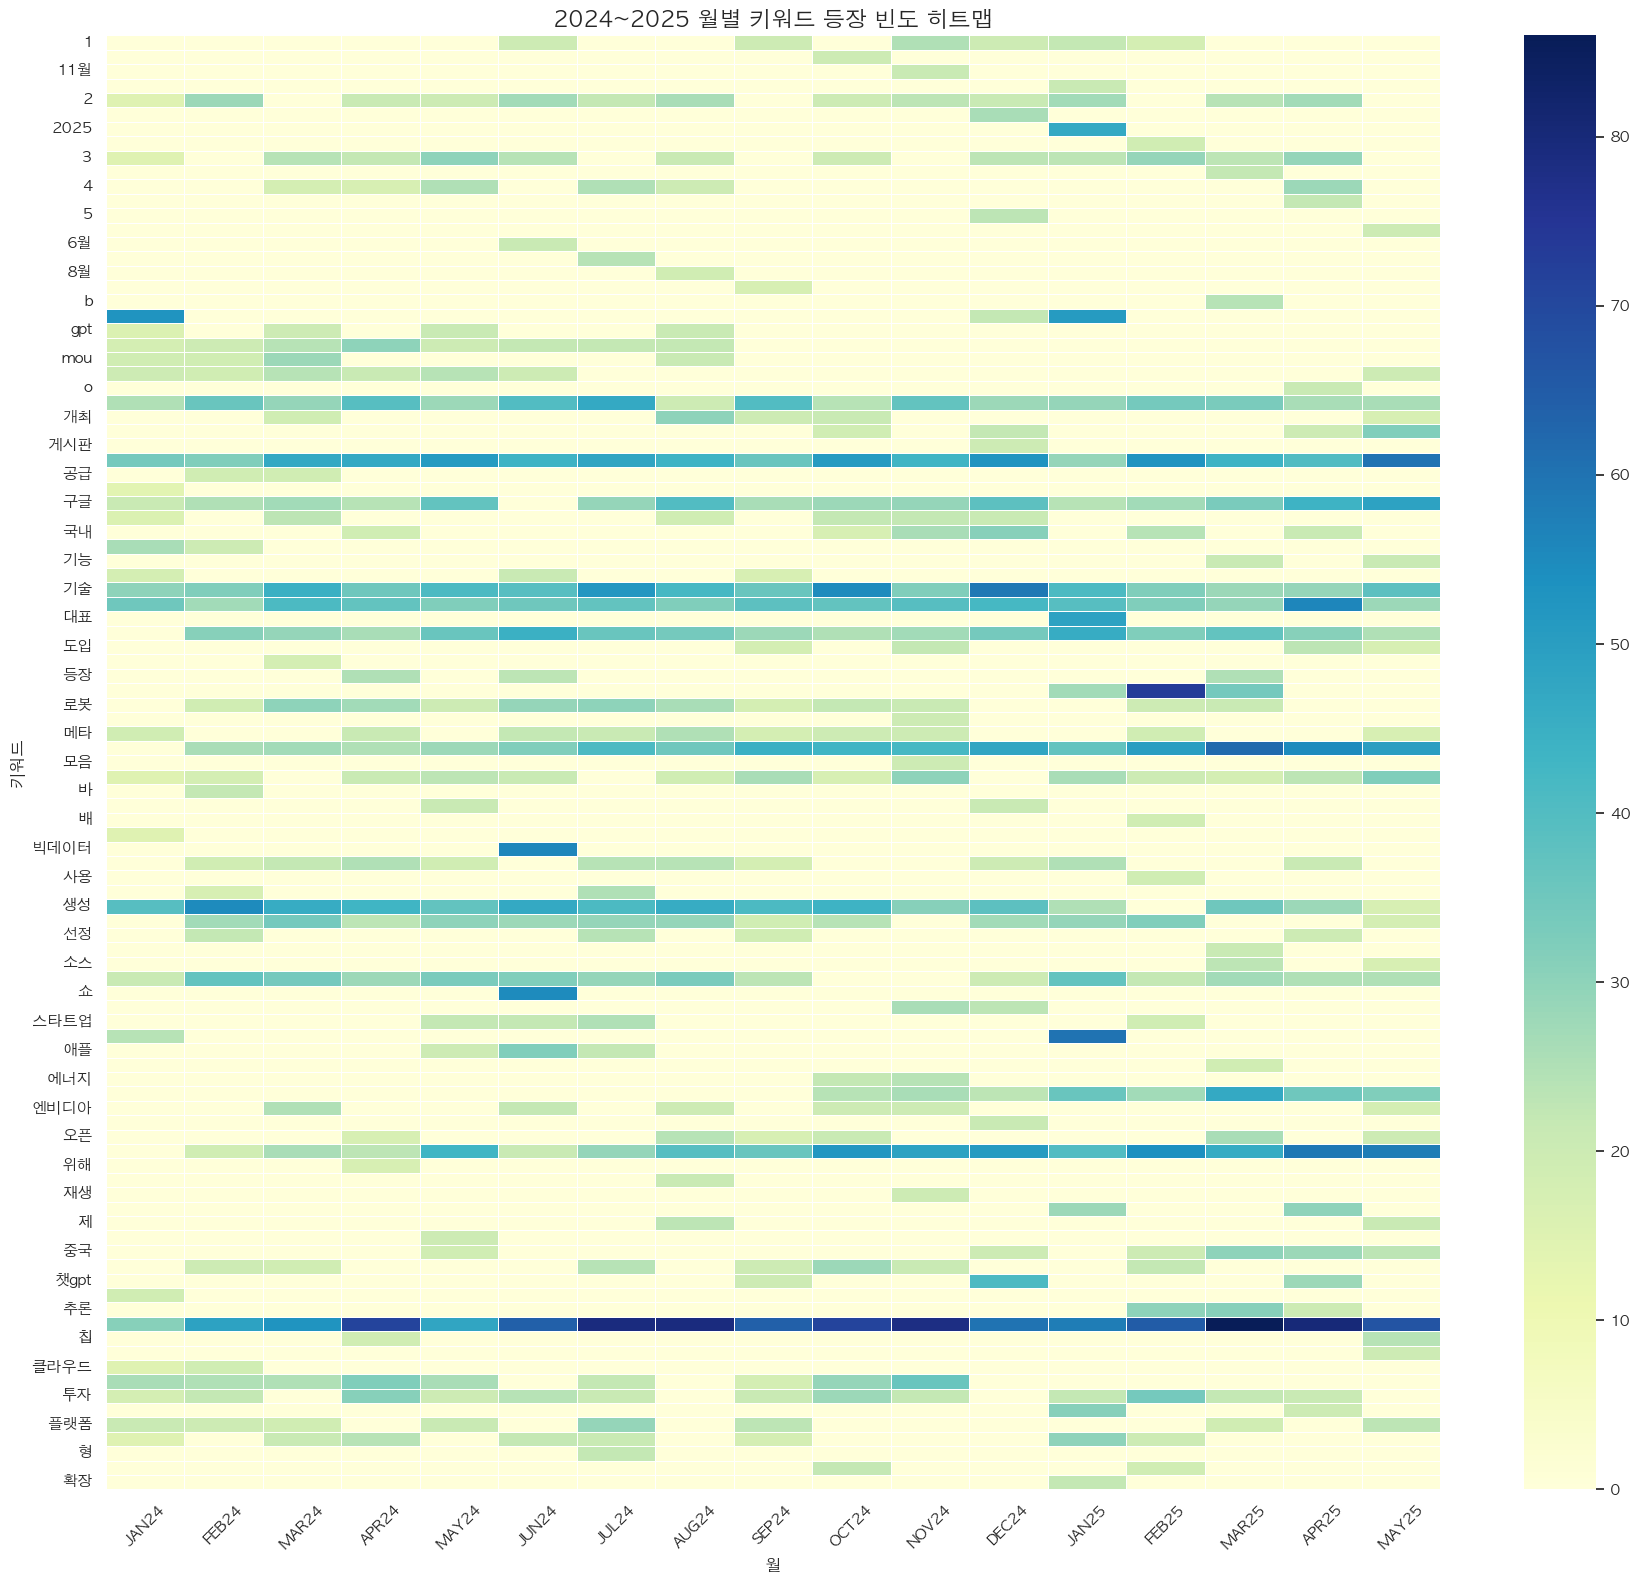

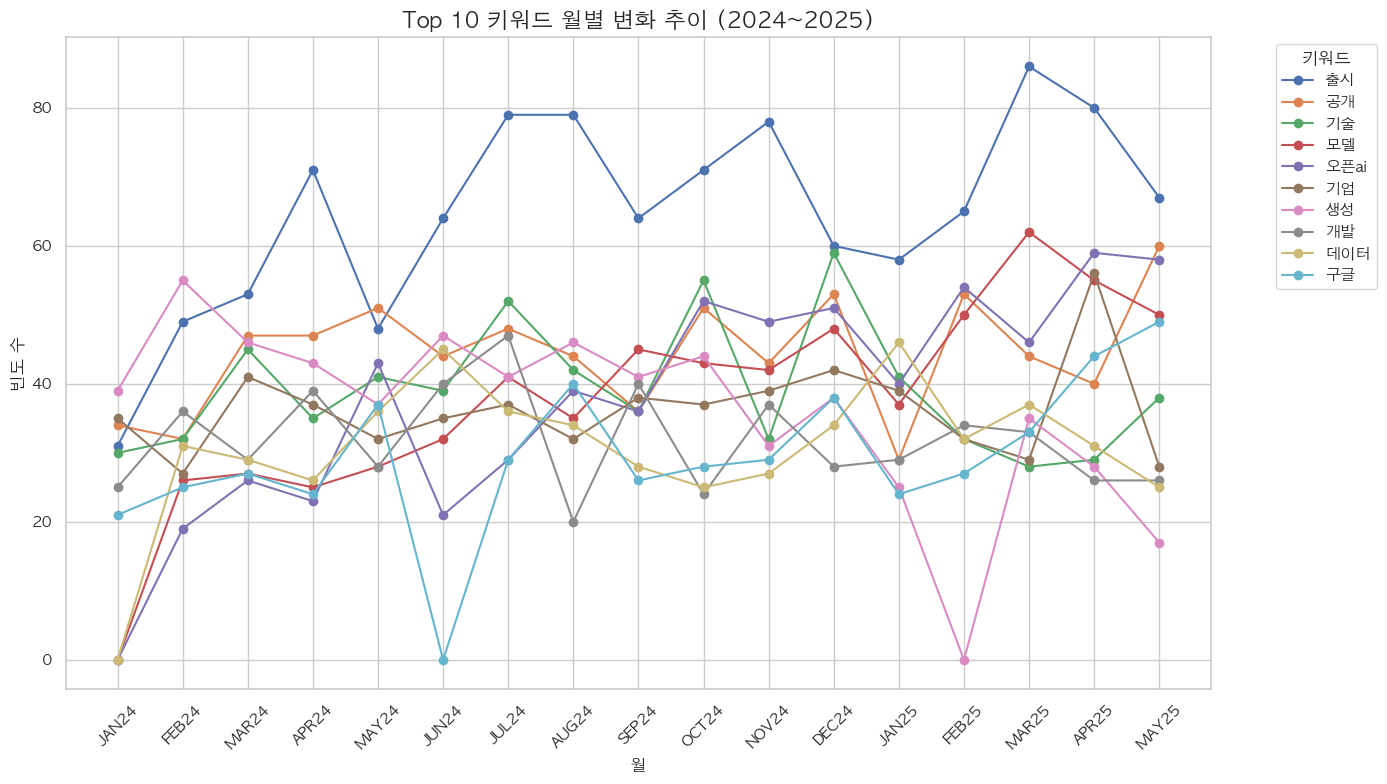

In [256]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# top_by_month 재정의 필요 → 사용자가 방금 코드에서 정의한 구조 사용

# 예시 DataFrame 구성: 실제 사용자는 top_by_month를 정의하고 있어야 함
# 여기에서는 top_2024, top_2025가 이미 존재한다고 가정

import platform

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS인 경우
# plt.rcParams['font.family'] = 'NanumGothic'  # 설치했을 때
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

############

if platform.system() == 'Windows':
    font_path = 'NanumFothic.ttf'
elif platform.system() == 'Darwin': #macOS
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else: #Assume Colab or Linux
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 1. 월별 키워드 등장 빈도 합산
monthly_keyword_counts = {}


# 2024년 처리
for label, df in top_2024.items():
    month_label = label.replace('_top', '').upper()
    keyword_counts = df.groupby('token')['count'].sum()
    monthly_keyword_counts[month_label] = keyword_counts

# 2025년 처리
for label, df in top_2025.items():
    month_label = label.replace('_top', '').upper()
    keyword_counts = df.groupby('token')['count'].sum()
    monthly_keyword_counts[month_label] = keyword_counts

# 2. 피벗 테이블 생성
all_keywords = sorted(set().union(*[s.index for s in monthly_keyword_counts.values()]))



trend_matrix = pd.DataFrame(index=all_keywords)

for month, counts in monthly_keyword_counts.items():
    trend_matrix[month] = counts

# 결측값 0으로 채우기
trend_matrix = trend_matrix.fillna(0).astype(int)

# 'ai' 키워드 제외 후 top 10 선정
filtered_matrix = trend_matrix.drop(index='ai', errors='ignore')  # 'ai' 없을 경우에도 안전

# 3. 히트맵 시각화
plt.figure(figsize=(18, 16))
sns.heatmap(filtered_matrix, cmap="YlGnBu", linewidths=0.5)
plt.title("2024~2025 월별 키워드 등장 빈도 히트맵", fontsize=16)
plt.xlabel("월", fontsize=12)
plt.ylabel("키워드", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. TOP 10 키워드 시계열 변화 시각화


top_keywords = filtered_matrix.sum(axis=1).sort_values(ascending=False).head(10).index
trend_top10 = filtered_matrix.loc[top_keywords]



plt.figure(figsize=(14, 8))
for kw in trend_top10.index:
    plt.plot(trend_top10.columns, trend_top10.loc[kw], marker='o', label=kw)
plt.title("Top 10 키워드 월별 변화 추이 (2024~2025)", fontsize=16)
plt.xlabel("월", fontsize=12)
plt.ylabel("빈도 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="키워드", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


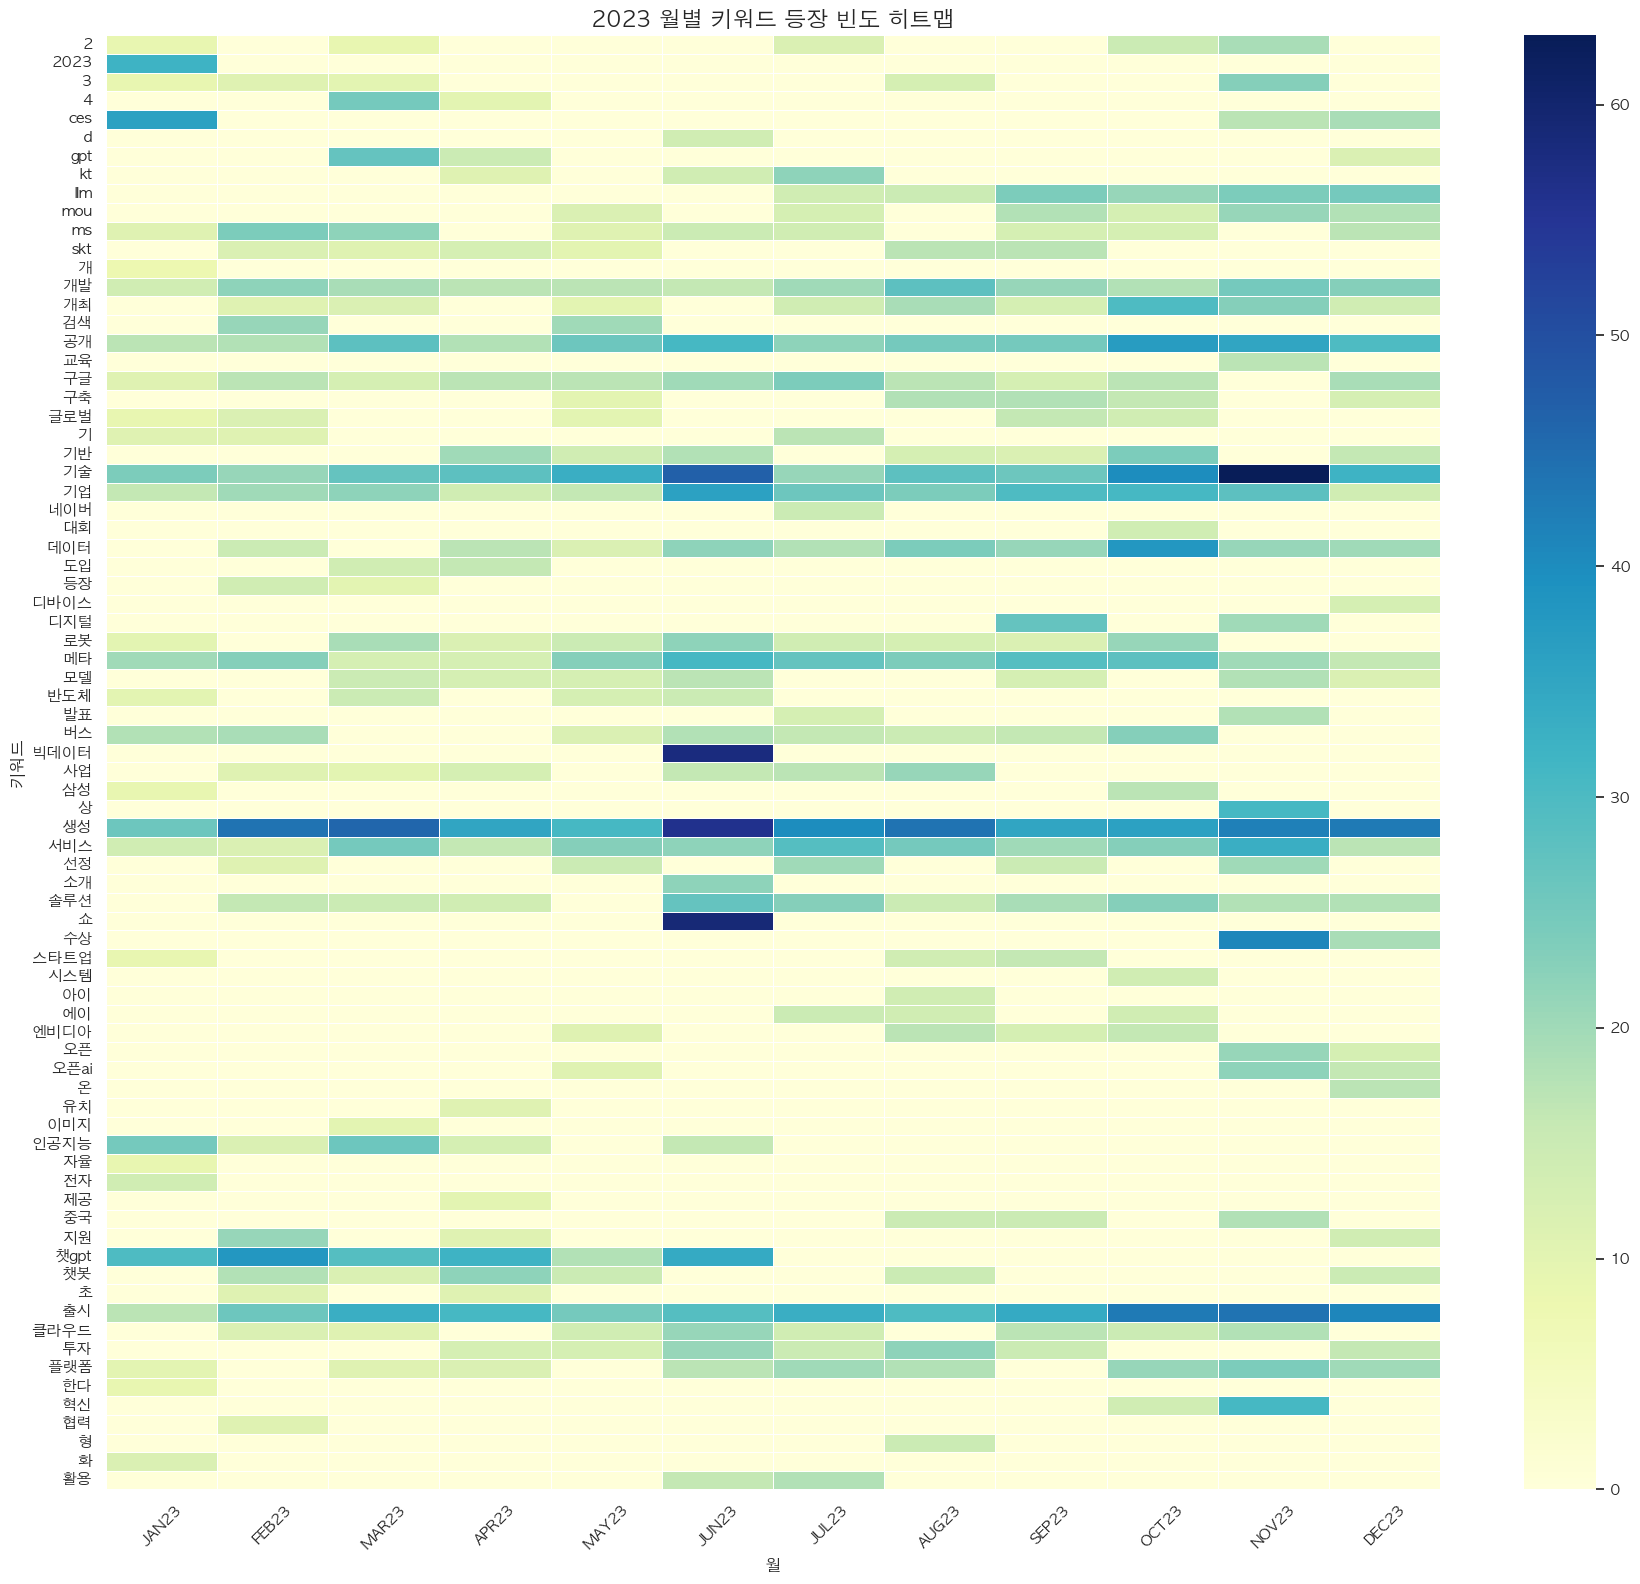

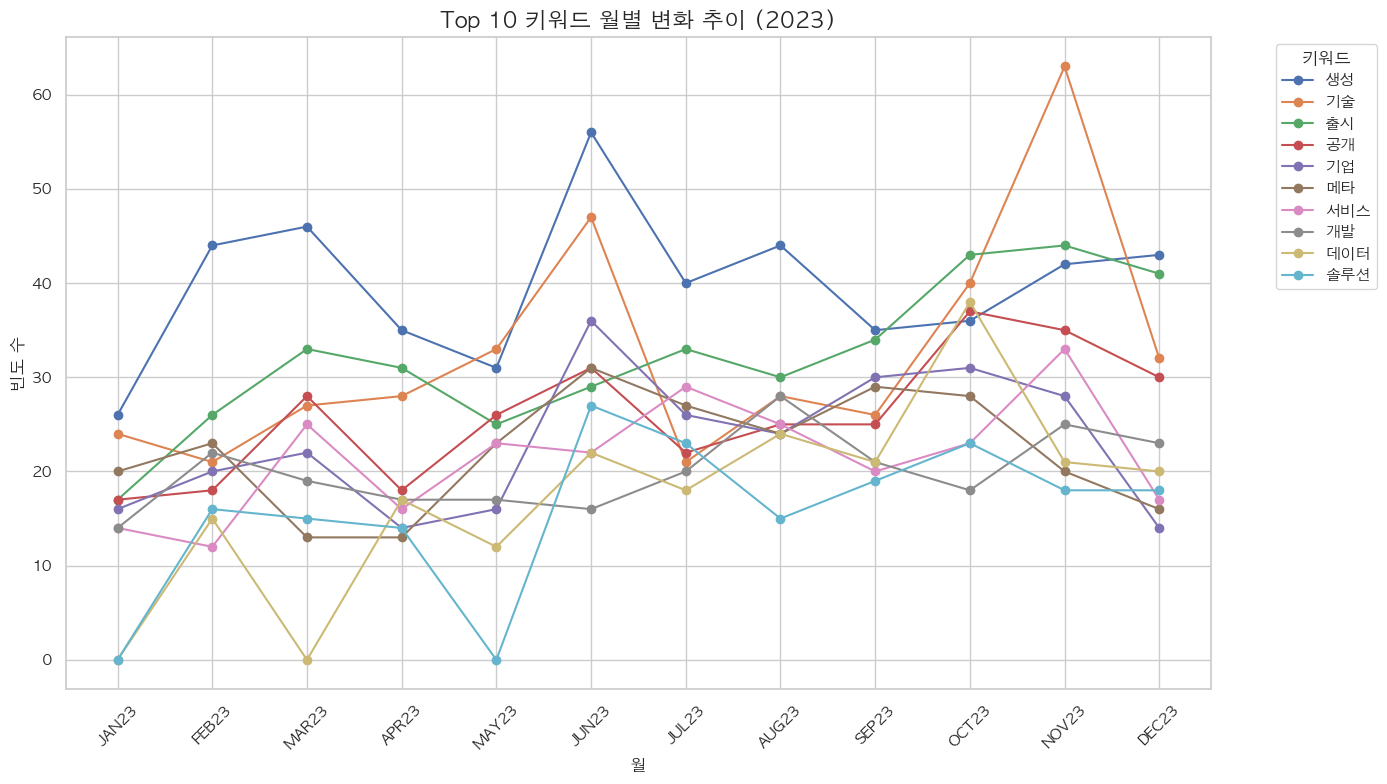

In [255]:
# 2023 
monthly_keyword2023_counts = {}
# 2023년 처리
for label, df in top_2023.items():
    month_label = label.replace('_top', '').upper()
    keyword_counts = df.groupby('token')['count'].sum()
    monthly_keyword2023_counts[month_label] = keyword_counts

#피벗테이블 생성
all_keywords2023 = sorted(set().union(*[s.index for s in monthly_keyword2023_counts.values()])) #2023 피벗테이블 

trend_matrix2023 = pd.DataFrame(index=all_keywords2023)

for month, counts in monthly_keyword2023_counts.items():
    trend_matrix2023[month] = counts

# 결측값 0으로 채우기
trend_matrix2023 = trend_matrix2023.fillna(0).astype(int)

# 'ai' 키워드 제외 후 top 10 선정
filtered_matrix2023 = trend_matrix2023.drop(index='ai', errors='ignore')  # 'ai' 없을 경우에도 안전


# 3. 히트맵 시각화
plt.figure(figsize=(18, 16))
sns.heatmap(filtered_matrix2023, cmap="YlGnBu", linewidths=0.5)
plt.title("2023 월별 키워드 등장 빈도 히트맵", fontsize=16)
plt.xlabel("월", fontsize=12)
plt.ylabel("키워드", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. TOP 10 키워드 시계열 변화 시각화


top_keywords2023 = filtered_matrix2023.sum(axis=1).sort_values(ascending=False).head(10).index
trend2023_top10 = filtered_matrix2023.loc[top_keywords2023]



plt.figure(figsize=(14, 8))
for kw in trend2023_top10.index:
    plt.plot(trend2023_top10.columns, trend2023_top10.loc[kw], marker='o', label=kw)
plt.title("Top 10 키워드 월별 변화 추이 (2023)", fontsize=16)
plt.xlabel("월", fontsize=12)
plt.ylabel("빈도 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="키워드", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


- 생성 : 거의 모든 달에 등장/ 생성형 ai 트렌드의 지속적 존재감을 나타낸다
- 출시 지속적으로 높은 빈도 / 실제 제품화. 상용화 활동 활발
- 기술 : 11월에 급증, 히트맵 보면 11월에 빈도수 높은 단어는 혁신/수상/출시/서비스/생성/상/기업/공개 >> 어떤 기업이 기술을 출시하여 수상했나? 예측 
- 메타/ 기업 6~12월 집중/ 기업 중심 키워드로 강화 

/var/folders/5h/9d1tm36x78vg7z4pjs8gzzv00000gn/T/ipykernel_7627/19798427.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trend_matrix_q = trend_matrix_q.groupby(axis=1, level=0).sum()


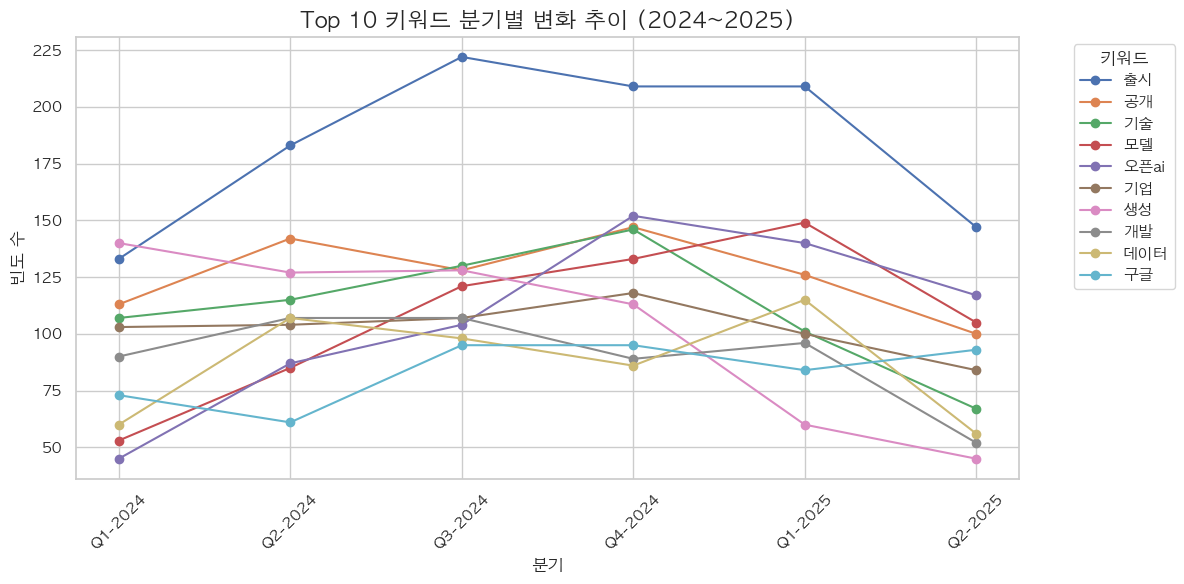

In [247]:
import pandas as pd
import matplotlib.pyplot as plt

# 가정: trend_matrix는 이미 월별 키워드 빈도가 저장된 상태
# 예: index=키워드, columns=['JAN24', ..., 'MAY25']

# 1. 월 → 분기 매핑 함수 정의
def map_month_to_quarter(month_str):
    month_map = {
        'JAN': 'Q1', 'FEB': 'Q1', 'MAR': 'Q1',
        'APR': 'Q2', 'MAY': 'Q2', 'JUN': 'Q2',
        'JUL': 'Q3', 'AUG': 'Q3', 'SEP': 'Q3',
        'OCT': 'Q4', 'NOV': 'Q4', 'DEC': 'Q4'
    }
    month = month_str[:3]
    year = '20' + month_str[-2:]
    return f"{month_map[month]}-{year}"

# 2. 각 컬럼(월)을 분기로 매핑
quarter_columns = [map_month_to_quarter(col) for col in trend_matrix.columns]

# 3. 분기별로 그룹화해서 합산

# 분기 컬럼 정렬
trend_matrix_q = filtered_matrix.copy()
trend_matrix_q.columns = quarter_columns
trend_matrix_q = trend_matrix_q.groupby(axis=1, level=0).sum()

ordered_quarters = sorted(trend_matrix_q.columns, key=lambda x: (x[-4:], x[:2]))  # 연도 → 분기순
trend_matrix_q = trend_matrix_q[ordered_quarters]


# 4. 상위 키워드 10개 추출 (분기 기준으로)
top_keywords_q = trend_matrix_q.sum(axis=1).sort_values(ascending=False).head(10).index
trend_top10_q = trend_matrix_q.loc[top_keywords_q]

# 5. 시각화
plt.figure(figsize=(12, 6))
for kw in trend_top10_q.index:
    plt.plot(trend_top10_q.columns, trend_top10_q.loc[kw], marker='o', label=kw)
plt.title("Top 10 키워드 분기별 변화 추이 (2024~2025)", fontsize=16)
plt.xlabel("분기", fontsize=12)
plt.ylabel("빈도 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="키워드", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Top 키워드를 통한 흐름 파악 
- 출시 : 전 기간에 걸쳐 꾸준히 상승 및 등장 -> 산업 전반의 상용화 중심 전략 강화
- 공개/기술/생성 : 2024 Q1~ Q4까지 꾸준히 등장 이후 공개 -> 완만한 하강/ 기술 -> 급하강 / 생성 -> 급하강
    기술 발표(공개) 중심에서 실용화로 이동 중
- 오픈 ai: 2024 Q3 부터 급증 , 2025까지 유지 
- 모델: 2024 Q2 부터 급증 , 2025까지 유지 
- 구글이 상위 키워드로 도출된 것으로 보아 ai 관련해 중요도가 높은 회사. 

- 월별 라인차트 보면 구글/ 모델 등은 특정 달에 강하게 출현 -> 이벤트/발표 중심의 키워드 
- 2025 2월 딥시크 파격 등장 

/var/folders/5h/9d1tm36x78vg7z4pjs8gzzv00000gn/T/ipykernel_7627/2420589242.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trend_matrix_q = trend_matrix_q.groupby(axis=1, level=0).sum()


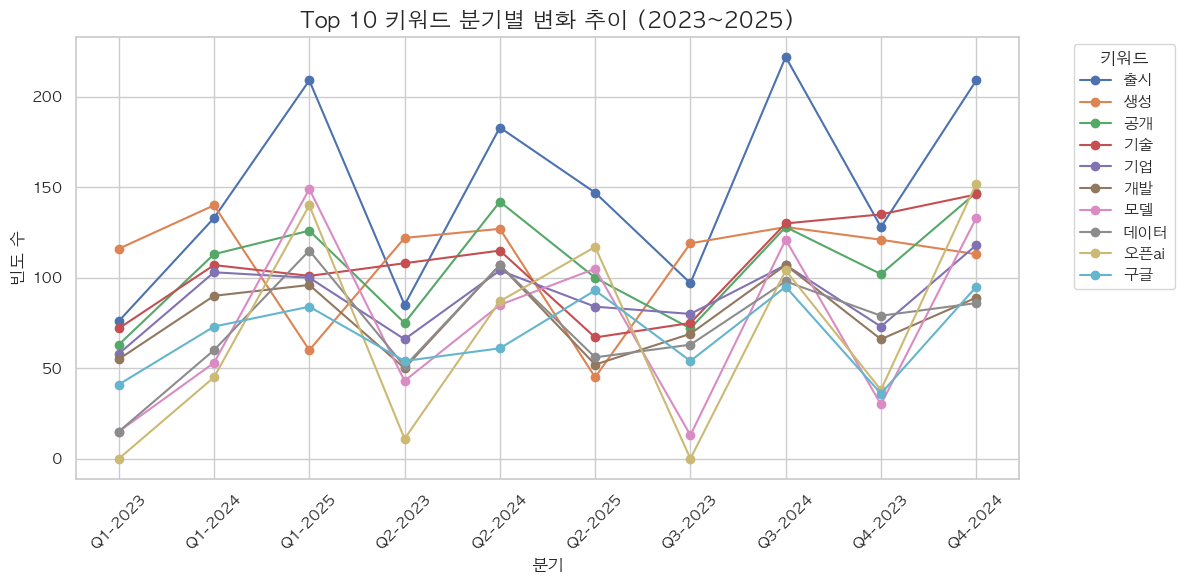

In [248]:
# 전체 기간 키워드 등장 테이블 결합
trend_matrix_all = pd.concat([trend_matrix2023, trend_matrix], axis=1)

quarter_columns = [map_month_to_quarter(col) for col in trend_matrix_all.columns]

trend_matrix_q = trend_matrix_all.copy()
trend_matrix_q.columns = quarter_columns
trend_matrix_q = trend_matrix_q.groupby(axis=1, level=0).sum()

# 1. ai 제외
trend_matrix_q_no_ai = trend_matrix_q.drop(index='ai', errors='ignore')

# 2. 다시 상위 10개 키워드 추출
top_keywords_q_no_ai = trend_matrix_q_no_ai.sum(axis=1).sort_values(ascending=False).head(10).index
trend_top10_q_no_ai = trend_matrix_q_no_ai.loc[top_keywords_q_no_ai]


# 정렬
ordered_quarters = sorted(trend_matrix_q_no_ai.columns, key=lambda x: (x[-4:], x[:2]))
trend_matrix_q_no_ai = trend_matrix_q_no_ai[ordered_quarters]


# 5. 시각화
plt.figure(figsize=(12, 6))
for kw in trend_top10_q_no_ai.index:
    plt.plot(trend_top10_q_no_ai.columns, trend_top10_q_no_ai.loc[kw], marker='o', label=kw)
plt.title("Top 10 키워드 분기별 변화 추이 (2023~2025)", fontsize=16)
plt.xlabel("분기", fontsize=12)
plt.ylabel("빈도 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="키워드", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 결론 
**2023~2024년은 기술 발표·생성형 AI 중심 → 2025년부터는 모델·플랫폼 기반 실용기술 강화 흐름으로 전환**

| 키워드 유형     | 특성                  | 대표 키워드   | 설명                              |
| ---------- | ------------------- | -------- | ------------------------------- |
| **브랜드 중심** | 기술 주도 기업 자체가 관심 대상  | 오픈AI, 구글 | 기술보다 **플레이어(기업)**가 트렌드를 끌고감 |
| **기술 적용형** | 실제 적용 가능 기술, 제품화 요소 | 출시, 모델   | 연구 단계 → **도입/적용 중심으로 이동**함을 반영  |

**빈도 기반 영향력 증거**
- 2023 초반에는 gpt, 챗gpt, 생성 등 기술 이론 키워드가 주도
- 이후 2024~2025로 갈수록: 출시/모델 → 지속적 확산 
- 오픈ai, 구글 → 특정 분기 집중 강세
- 시간에 따라 중심 키워드가 ‘실행/기업’ 중심으로 전환되었음

**2023년에는 GPT, 생성형 AI와 같은 기술 그 자체가 트렌드의 중심이었다면,
2024~2025년에는 `누가(브랜드)` `무엇을(모델)` `어떻게 적용했는가(출시)`가
트렌드의 핵심으로 전환되고 있다는 것이 관찰 결과.**


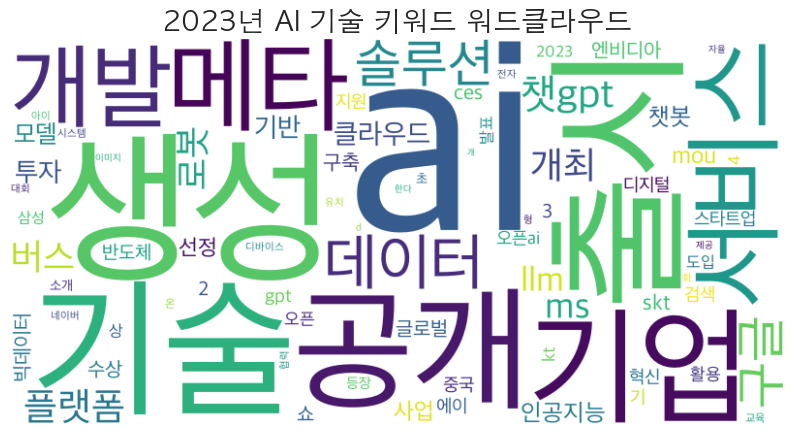

In [ ]:
# 키워드 총 빈도 구하기
total_2023_counts = trend_matrix2023.sum(axis=1)

# 워드클라우드 생성
wc = WordCloud(
   font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(total_2023_counts)

# 3. 시각화
plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("2023년 AI 기술 키워드 워드클라우드", fontsize=20)
plt.show()

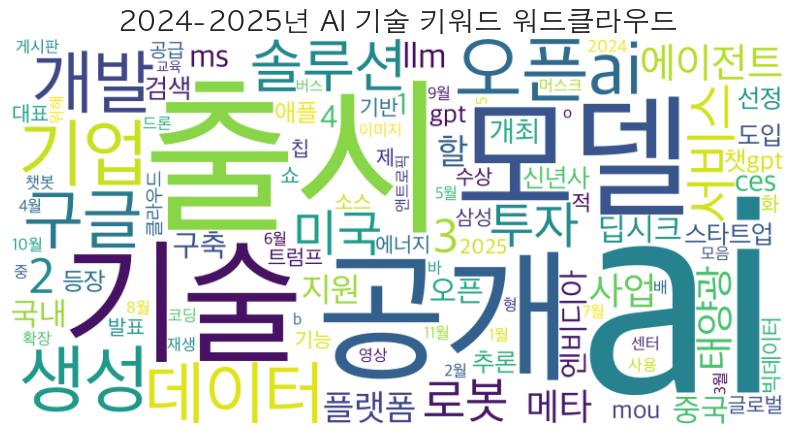

In [ ]:
# 키워드 총 빈도 구하기
total_2024_2025_counts = trend_matrix.sum(axis=1)

# 워드클라우드 생성
wc = WordCloud(
   font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(total_2024_2025_counts)

# 3. 시각화
plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("2024-2025년 AI 기술 키워드 워드클라우드", fontsize=20)
plt.show()

---
# [진행중]
# 2. 형태소 분석 [본문]

### 1) 본문 데이터를 준비
### 2) 형태소 분석 → 불용어 제거 
    형태소 분석을 하다보니, 중요한 기술 키워드 인데 단어가 분리되는 현상이 있다. 예를 들어 '허깅 페이스' 가 '허', '깅', '페이스' 라고 인식된다. 
    이런 단어들을 병합 키워드 딕셔너리로 만들어 주는 작업을 진행했다.
- Word2Vec (Skip-gram) 학습 → 단어 임베딩 추출
- 유사도 분석, 시각화, 자동 키워드 확장 등에 활용 


### 📌 1) 본문 데이터 준비 

#### 2024년 1월 ~ 2025 5월 범위(17개월)로 뉴스를 필터링 한다. 
- 2025 6월 데이터는 데이터가 충분하지 않아 올바른 분석을 하지 못하므로 제외시켰다. 
- `df_filtered` :   2024년 1월 ~ 2025 5월로 필터링된 데이터 

In [6]:
# 날짜 컬럼이 문자열이라면 datetime으로 변환
df['date'] = pd.to_datetime(df['date'])

# 2025년 1월 ~ 6월 범위 필터링
start_date = '2024-01-01'
end_date = '2025-05-31'

df_filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

#### 뉴스 본문 추출 `body_texts`

In [7]:
body_texts = df_filtered['body']

### 📌 2) 형태소 분석 

In [ ]:
# 형태소 분석 
import sys
sys.path.append('../../') # 상위 폴더 접근 허용 

from analysis.preprocess_module import preprocess_text, remove_stopwords

#형태소 분석 적용 
body_tokens = body_texts.apply(preprocess_text)

#불용어 정의 
stopwords = set([
    "의", "이", "가", "은", "는", "을", "를", "에", "에서", "도", "로", "으로", "있", "들", "그", "되", "의", "및", "위",
    "한", "하다", "되다", "및", "이다", "그리고", "하지만", "또한", "수", "것", "등", "같", 
])

number_patterns = []
for text in (df['title'].fillna('') + ' ' + df['body'].fillna(''))[:100]:  # 샘플만
    # 수치 + 단위 패턴
    numbers = re.findall(r'\d+(?:.\d+)?(?:억|만|천|조|%|달러|원|GB|TB|MB)', text)
    number_patterns.extend(numbers)

# 불용어 추출
total_articles = len(df)

for word, count in nouns_counter.most_common(1000):
    # 길이가 짧은 조사(은, 는, 이, 가 등)와 불용어 추출
    if len(word) < 2:
        domain_stopwords.append(word) 




#불용어 제거 
filtered_body_tokens = body_tokens.apply(lambda tokens: remove_stopwords(tokens, stopwords))

                                           
for i in range(5):  
    print(f"\n🔹 [{i+1}번째]")
    print("불용어 제거 전:", body_tokens.iloc[i][:20])   # 너무 길 경우 앞 20개만 표시
    print("불용어 제거 후:", filtered_body_tokens.iloc[i][:20])
    print("-" * 50)


🔹 [1번째]
불용어 제거 전: ['일', '론', '머스크', 'ceo', '가', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '을', '포함', '한', '약물', '을', '다량', '복용', '했다는']
불용어 제거 후: ['일', '론', '머스크', 'ceo', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '포함', '약물', '다량', '복용', '했다는', '주장', '뉴욕', '타임스', 'nyt']
--------------------------------------------------

🔹 [2번째]
불용어 제거 전: ['구글', '의', '검색', '독점', '해소', '안', '을', '결정', '할', '미국', '재판', '에서', '판사', '가', '인공', '지능', 'ai', '이', '검색', '의']
불용어 제거 후: ['구글', '검색', '독점', '해소', '안', '결정', '할', '미국', '재판', '판사', '인공', '지능', 'ai', '검색', '경쟁', '기술', '인지', '대해', '의문', '가지']
--------------------------------------------------

🔹 [3번째]
불용어 제거 전: ['바이브', '코딩', '이', '인기', '를', '끄는', '가운데', '인공', '지능', 'ai', '이', '생', '성', '한', '코드', '가', '작동', '하지', '않거나', '보안']
불용어 제거 후: ['바이브', '코딩', '인기', '끄는', '가운데', '인공', '지능', 'ai', '생', '성', '코드', '작동', '하지', '않거나', '보안', '문제', '일으킬', '있다는', '지적', '나왔다']
--------------------------------------------------

🔹 [4번째]
불용어 제거 전: ['대형', '언어', '모델', 'llm'

In [44]:
#키워드 병합 함수 
def merge_keywords(tokens, merge_dict):
    merged = [] #병합된 결과를 반환할 리스트 
    i = 0 # 토큰 리스트의 현재 위치 인덱스 
    while i < len(tokens):
        found = False
        for length in [3, 2]:  # 3단어 조합 우선 → 2단어 조합
            group = tuple(tokens[i:i+length])
            if group in merge_dict:
                merged.append(merge_dict[group])
                i += length
                found = True
                break
        if not found:
            merged.append(tokens[i])
            i += 1
    return merged


# 병합 딕셔너리 정의
merge_dict = {
    ('인공', '지능'): '인공지능',
    ('오픈', 'ai'): '오픈ai',
    ('생', '성'): '생성',
    ('허', '깅', '페이스'): '허깅페이스',
    ('챗', 'gpt'): '챗gpt',
    ('chat', 'gpt'): '챗gpt',
    ('양자', '컴퓨터'): '양자컴퓨팅',
    ('양자', '컴퓨팅'): '양자컴퓨팅',
    ('자연어', '처리'): 'nlp',
    ('이미지', '처리'): '이미지처리',
    ('대형','언어', '모델'): '대형언어모델',
    ('바이브','코딩'): '바이브코딩'
}


# 병합 함수 적용
merged_tokens = filtered_body_tokens.apply(lambda tokens: merge_keywords(tokens, merge_dict))


In [45]:
# 병합 결과 확인
for i in range(5):
    print(f"\n🔹 [{i+1}번째 뉴스]")
    print("병합 전:", filtered_body_tokens.iloc[i])
    print("병합 후:", merged_tokens.iloc[i])
    print("-" * 50)



🔹 [1번째 뉴스]
병합 전: ['일', '론', '머스크', 'ceo', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '포함', '약물', '다량', '복용', '했다는', '주장', '뉴욕', '타임스', 'nyt', '내놓았다', '대해', '머스크', 'ceo', '허위', '보도', '신문사', '라고', '비난', '했다', 'nyt', '30일', '현지', '시간', '소식통', '인용', '머스크', 'ceo', '지난해', '도널드', '트럼프', '대통령', '선거', '유세', '지원', '하는', '도중', '엑스터시', '와', '혼각', '버섯', '포함', '약물', '다량', '복용', '했으며', '이로', '인한', '부작용', '주변', '사람', '에게', '털어', '놓았다고', '보도', '했다', '머스크', 'ceo', '잘', '아는', '사람', '따르면', '각성제', '인', '애더럴', '포함', '해', '알약', '20', '개', '든', '상자', '가지', '고', '다녔으며', '약물', '사용', '일상', '적', '인', '수준', '넘었다고', '전', '했다', '특히', '케타민', '과도', '하게', '복용', '해', '방광', '문제', '생긴다고', '주변', '알렸다는', '백악관', '합류', '이후', '약물', '계속', '복용', '했는지는', '불분명', '하다고', '전', '했다', '내각', '구성원', '비난', '하고', '행사', '에서는', '나치', '식', '경례', '물의', '일으키는', '불안정한', '행동', '이어', '갔다', '이전', '에도', '약물', '손', '댔다는', '이야기', '소개', '했다', '소셜', '미디어', '통해', '엄청난', '행복감', '과', '끔찍한', '침체', '끊임없는', '스트레스', '느꼈다라고', '말', '했다', '또', '전통', '적', '인', '치료

# 3. 키워드 분석

In [46]:
from collections import Counter

# 평탄화
merged_body_keywords = [token for tokens in merged_tokens for token in tokens]

# 빈도 계산
keyword_counts = Counter(merged_body_keywords)
top_keywords = keyword_counts.most_common(50)

# 상위 30개 출력
for rank, (word, count) in enumerate(top_keywords, ):
    print(f"{rank:2}. {word:<10} : {count}회")


 0. ai         : 59735회
 1. 했다         : 41099회
 2. 할          : 29659회
 3. 하는         : 26437회
 4. 과          : 24644회
 5. 적          : 24250회
 6. 와          : 22685회
 7. 모델         : 18361회
 8. 인          : 17439회
 9. 하고         : 16595회
10. 기술         : 16563회
11. 있다         : 15973회
12. 해          : 15469회
13. 데이터        : 13350회
14. 다          : 13149회
15. 기업         : 12569회
16. 통해         : 11778회
17. 개발         : 10834회
18. 밝혔다        : 10611회
19. 말          : 10524회
20. 된          : 10294회
21. 대표         : 10042회
22. 서비스        : 9848회
23. 전          : 9680회
24. 사용         : 8761회
25. 있는         : 8655회
26. 생성         : 8601회
27. 에는         : 8496회
28. 오픈ai       : 8357회
29. 이라고        : 8140회
30. 제공         : 8044회
31. 위          : 7991회
32. 또          : 7985회
33. 활용         : 7840회
34. 인공지능       : 7745회
35. 기반         : 7570회
36. 이번         : 7429회
37. 기능         : 7284회
38. 사용자        : 7098회
39. 출시         : 6890회
40. 위해         : 6865회
41. 설명         : 6758회
42. 고       

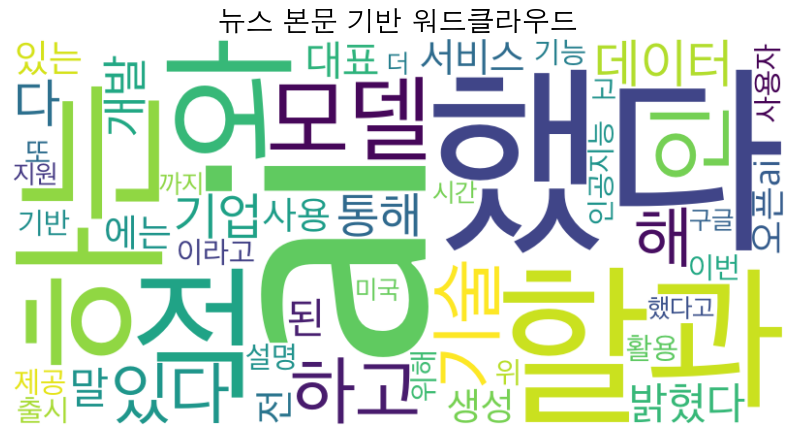

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import platform
##############
from collections import Counter
import matplotlib.font_manager as fm

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS인 경우
# plt.rcParams['font.family'] = 'NanumGothic'  # 설치했을 때
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

############

if platform.system() == 'Windows':
    font_path = 'NanumFothic.ttf'
elif platform.system() == 'Darwin': #macOS
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else: #Assume Colab or Linux
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    
# 워드클라우드 생성
wc = WordCloud(
   font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(dict(top_keywords))

# 3. 시각화
plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("뉴스 본문 기반 워드클라우드", fontsize=20)
plt.show()


# 클러스터링 

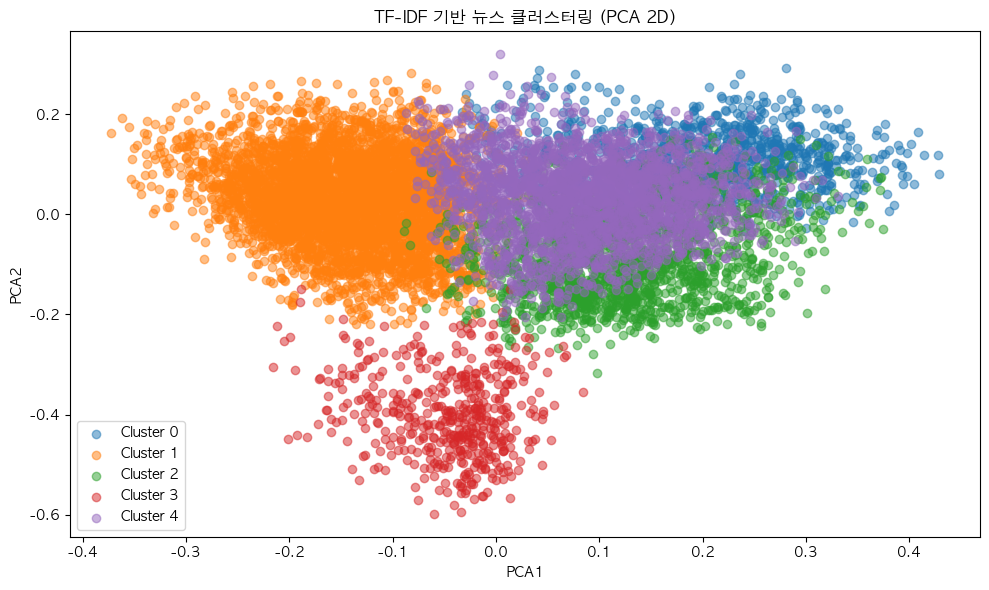

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. TF-IDF 벡터화
corpus = [' '.join(tokens) for tokens in merged_tokens]
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000) #2개 이상의 문서에 등장해야 포함, 전체 문서의 95퍼센트 이상 등장하는 단어 제거 
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

# 2. KMeans 클러스터링
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# 3. 클러스터별 상위 키워드 추출
top_keywords_per_cluster = []
for i in range(n_clusters):
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[::-1][:10]
    top_keywords = [feature_names[idx] for idx in top_indices]
    top_keywords_per_cluster.append(top_keywords)

# 4. 결과 데이터프레임 생성
df_result = df_filtered.copy().reset_index(drop=True)
df_result["cluster"] = labels

# 5. 차원 축소 (PCA) 및 시각화
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

df_result["pca1"] = X_reduced[:, 0]
df_result["pca2"] = X_reduced[:, 1]

# 시각화
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    cluster_data = df_result[df_result["cluster"] == i]
    plt.scatter(cluster_data["pca1"], cluster_data["pca2"], label=f"Cluster {i}", alpha=0.5)

plt.title("TF-IDF 기반 뉴스 클러스터링 (PCA 2D)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.tight_layout()
plt.show()




In [49]:
# 클러스터 중심 키워드 추출
top_keywords_per_cluster = []

for i in range(n_clusters):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:10]
    keywords = [feature_names[idx] for idx in top_indices]
    top_keywords_per_cluster.append(keywords)

# 보기 좋게 출력
for i, keywords in enumerate(top_keywords_per_cluster):
    print(f"\n{i}. Cluster {i} 주요 키워드:")
    print(" + ".join(keywords))



0. Cluster 0 주요 키워드:
모델 + 했다 + 추론 + 성능 + ai + llm + 하는 + 데이터 + 오픈 + 소스

1. Cluster 1 주요 키워드:
ai + 대표 + 기술 + 했다 + 솔루션 + 서비스 + 기업 + 데이터 + 사업 + 하는

2. Cluster 2 주요 키워드:
오픈ai + ai + ceo + 했다 + 중국 + 입니다 + 투자 + 미국 + 엔비디아 + 머스크

3. Cluster 3 주요 키워드:
태양광 + 에너지 + 전력 + 재생 + 설치 + 발전 + 발전소 + 풍력 + 했다 + gw

4. Cluster 4 주요 키워드:
ai + 했다 + 사용자 + 하는 + 기능 + 생성 + 구글 + 있다 + 사용 + 이미지


| 클러스터      | 중심 키워드     | 산업 방향성                |
| --------- | ---------- | --------------------- |
| Cluster 0 | 모델 성능 + 추론 | **LLM 성능 비교, 모델 최적화** |
| Cluster 1 | 기업 솔루션     | **AI 솔루션 비즈니스화**      |
| Cluster 2 | 글로벌 기업/정책  | **AI 생태계 전략 경쟁**      |
| Cluster 3 | 에너지 산업     | **AI + ESG + 재생에너지**  |
| Cluster 4 | 생성형 UX     | **개인화 중심 생성형 AI 서비스** |


/var/folders/5h/9d1tm36x78vg7z4pjs8gzzv00000gn/T/ipykernel_51076/3292102876.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


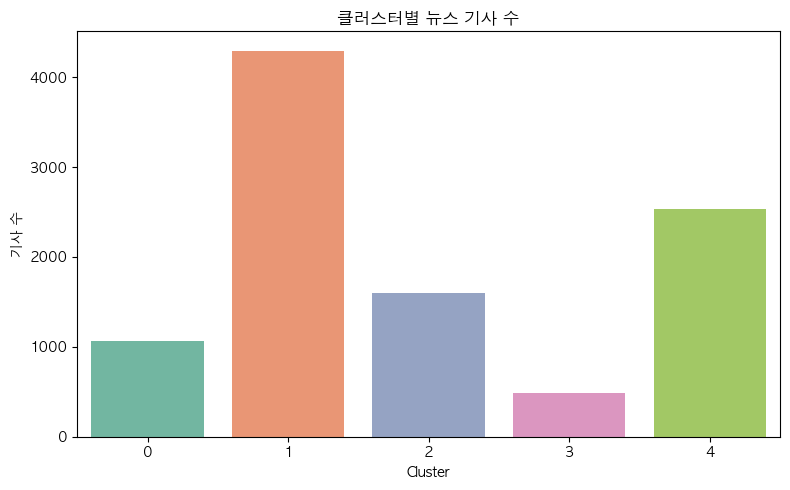

In [50]:
# 클러스터별 뉴스 수 비율 분석

import seaborn as sns
import matplotlib.pyplot as plt

# 클러스터 결과 복원
df_result = df_filtered.copy().reset_index(drop=True)
df_result["cluster"] = labels
df_result["pca1"] = X_reduced[:, 0]
df_result["pca2"] = X_reduced[:, 1]

# 클러스터별 뉴스 수 비율 계산
cluster_counts = df_result["cluster"].value_counts().sort_index()
cluster_percent = cluster_counts / cluster_counts.sum() * 100

# 막대그래프 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.title("클러스터별 뉴스 기사 수")
plt.xlabel("Cluster")
plt.ylabel("기사 수")
plt.tight_layout()
plt.show()


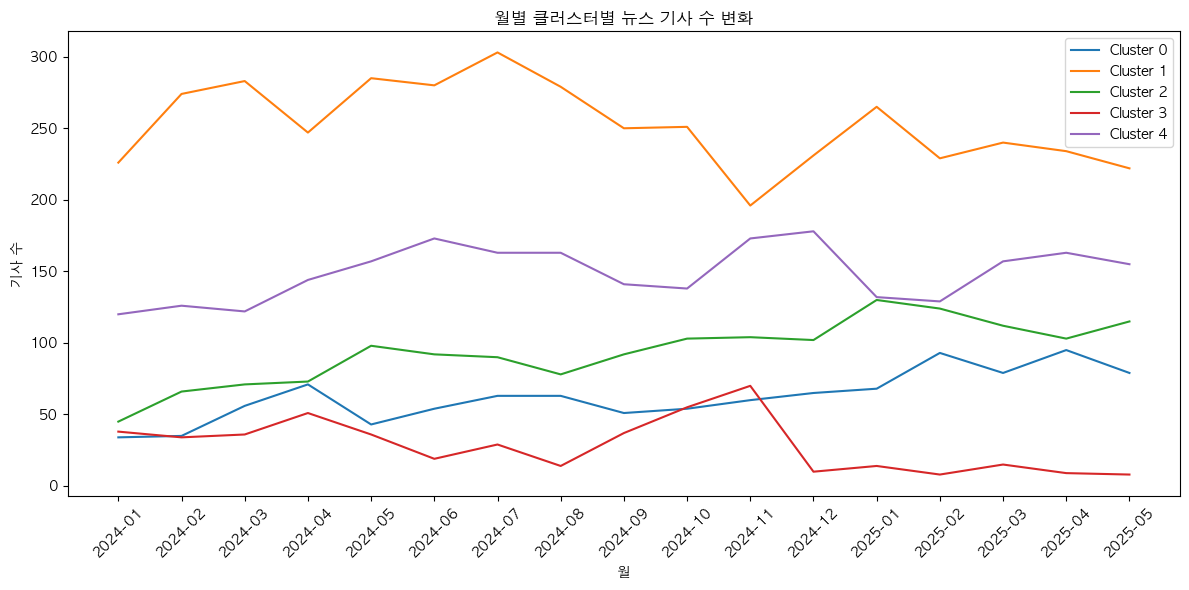

In [51]:
# 날짜 정보와 클러스터 ID를 기반으로 월별 뉴스 수 집계
df_result["date"] = pd.to_datetime(df_result["date"])
df_result["month"] = df_result["date"].dt.to_period("M")
df_cluster_month = df_result.groupby(["month", "cluster"]).size().reset_index(name="count")

# 클러스터별 월별 추이 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for cluster_id in sorted(df_cluster_month["cluster"].unique()):
    data = df_cluster_month[df_cluster_month["cluster"] == cluster_id]
    plt.plot(data["month"].astype(str), data["count"], label=f"Cluster {cluster_id}")

plt.title("월별 클러스터별 뉴스 기사 수 변화")
plt.xlabel("월")
plt.ylabel("기사 수")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## cluster1의 상위 키워드 추출 및 확인

In [52]:
# 인덱스 재정렬 
merged_tokens = merged_tokens.reset_index(drop=True)
df_result = df_result.reset_index(drop=True)

# Cluster 1 문서 추출
cluster_1_docs = df_result[df_result["cluster"] == 1]

# 토큰 병합
corpus_1 = [' '.join(merged_tokens[i]) for i in cluster_1_docs.index]


# TF-IDF 기반 핵심 키워드 추출
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=1000)
X = vectorizer.fit_transform(corpus_1)
feature_names = vectorizer.get_feature_names_out()
avg_tfidf = X.mean(axis=0).A1

# 결과 정리
import pandas as pd
df_keywords = pd.DataFrame({
    "keyword": feature_names,
    "avg_tfidf": avg_tfidf
}).sort_values(by="avg_tfidf", ascending=False)

# 상위 30개 키워드 출력
df_keywords.head(30)


,keyword,avg_tfidf
49,ai,0.130233
199,기술,0.053051
255,데이터,0.045551
443,서비스,0.042837
242,대표,0.042741
200,기업,0.042464
924,하는,0.041619
476,솔루션,0.037341
921,하고,0.034407
103,개발,0.033011


# TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석하기 

In [53]:
from gensim.models import Word2Vec

# 1. Cluster 1 문서에 포함된 토큰 리스트만 추출
cluster_1_tokens = [merged_tokens[i] for i in cluster_1_docs.index]

# 2. Word2Vec 모델 학습
w2v_model = Word2Vec(
    sentences=cluster_1_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,  # skip-gram
    seed=42
)

# 3. 상위 TF-IDF 키워드 중 일부 키워드의 유사 단어 보기
# 예시 키워드 선택 (TF-IDF 상위)
sample_keywords = df_keywords.head(10)["keyword"].tolist()
similar_words_dict = {}

for keyword in sample_keywords:
    if keyword in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(keyword, topn=10)
        similar_words_dict[keyword] = similar_words

# 결과 보기
import pandas as pd

# 키워드별 유사 단어 DataFrame으로 정리
similar_words_flat = []
for key, values in similar_words_dict.items():
    for word, score in values:
        similar_words_flat.append({"base_keyword": key, "similar_word": word, "similarity": score})

df_similar = pd.DataFrame(similar_words_flat)



In [54]:
print("📌 TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석\n")

for keyword, similar_list in similar_words_dict.items():
    print(f"🔹 '{keyword}' 와 의미상 유사한 단어 Top 10:")
    for word, score in similar_list:
        print(f"   - {word} ({score:.4f})")
    print()

📌 TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석

🔹 'ai' 와 의미상 유사한 단어 Top 10:
   - dap (0.6827)
   - al (0.6752)
   - aid (0.6731)
   - edpp (0.6705)
   - goover (0.6654)
   - 연합학습 (0.6638)
   - helpnow (0.6615)
   - 뛰어넘어 (0.6601)
   - 문헌정보 (0.6560)
   - do (0.6559)

🔹 '기술' 와 의미상 유사한 단어 Top 10:
   - 합하면 (0.6822)
   - 양자컴퓨터 (0.6819)
   - 겸비 (0.6658)
   - 무장 (0.6598)
   - 두루 (0.6585)
   - 합하여 (0.6583)
   - 다시금 (0.6578)
   - 국수 (0.6556)
   - 성공사례 (0.6528)
   - 앞세워 (0.6521)

🔹 '데이터' 와 의미상 유사한 단어 Top 10:
   - 수집 (0.7066)
   - 방대한 (0.6935)
   - 정제 (0.6906)
   - 라벨 (0.6901)
   - 가공 (0.6868)
   - 셋 (0.6761)
   - 링 (0.6666)
   - 상권 (0.6506)
   - 말뭉치 (0.6430)
   - 병렬 (0.6421)

🔹 '서비스' 와 의미상 유사한 단어 Top 10:
   - 젠투 (0.6801)
   - 밀착 (0.6748)
   - 헬프 (0.6740)
   - 랜딩존 (0.6737)
   - 콜센터 (0.6733)
   - 퓰리처 (0.6718)
   - 솔루션 (0.6663)
   - ixio (0.6632)
   - 구독 (0.6624)
   - api (0.6620)

🔹 '대표' 와 의미상 유사한 단어 Top 10:
   - 전문 (0.6649)
   - 변성준 (0.6366)
   - 김영 (0.6165)
   - 신년사 (0.6101)
   - 자회사 (0.6092)
   - 엠 (0.607

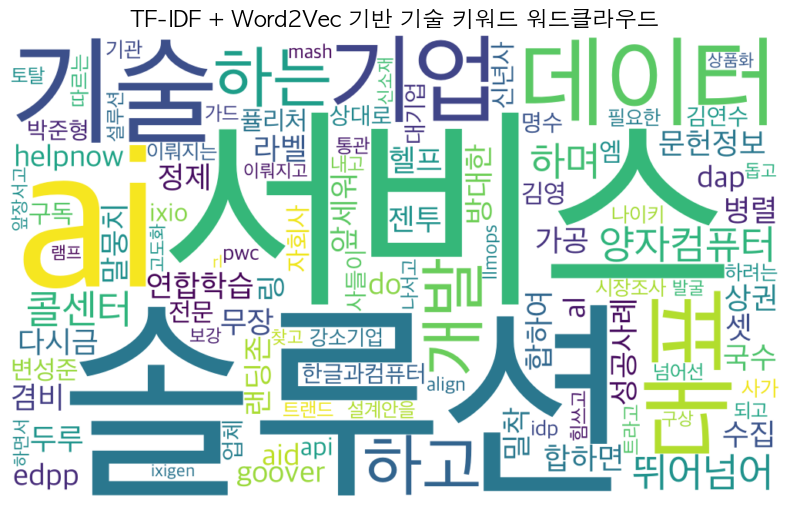

In [55]:
# 1. 모든 유사 단어 결과를 평탄화하여 DataFrame 생성
similar_words_flat = []
for base_keyword, similar_list in similar_words_dict.items():
    for word, score in similar_list:
        similar_words_flat.append({
            "base_keyword": base_keyword,
            "similar_word": word,
            "similarity": score
        })

df_word2vec_mapped = pd.DataFrame(similar_words_flat)


# 모든 키워드를 평탄화 (base + similar)
words = df_word2vec_mapped["base_keyword"].tolist() + df_word2vec_mapped["similar_word"].tolist()
word_freq = Counter(words)

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color="white",
    width=1000,
    height=600
).generate_from_frequencies(word_freq)


# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF + Word2Vec 기반 기술 키워드 워드클라우드", fontsize=16)
plt.show()


In [56]:
# ces 기술 키워드 기반 활용할 방법이 있을까...? 흠...
# ces_keyword_dict = {
#     "AI": ["ai", "인공지능", "agentic ai", "on-device ai", "edge ai"],
#     "Generative AI": ["generative ai", "생성형 ai", "생성형 인공지능", "llm", "대규모 언어 모델", "대규모언어모델", "chatgpt", "챗gpt", "오픈ai", "openai"],
#     "Smart Home": ["스마트홈", "smart home", "홈ai", "home ai", "iot", "스마트 가전", "smart appliances", "스마트링", "smart ring"],
#     "Mobility": ["모빌리티", "mobility", "자율주행", "autonomous vehicle", "evtol", "전기차", "ev", "스마트 모빌리티"],
#     "XR": ["xr", "ar", "vr", "ar/vr", "확장현실", "가상현실", "증강현실", "spatial computing", "스마트글래스", "smart glasses", "스마트 안경"],
#     "Digital Health": ["디지털 헬스케어", "digital health", "remote monitoring", "at-home diagnostics", "스마트 헬스케어", "헬스케어 ai"],
#     "Robotics": ["로봇", "로보틱스", "robotics", "개인용 로봇", "companion robot", "서비스 로봇", "농업 로봇"],
#     "Quantum Computing": ["양자컴퓨터", "quantum computing", "퀀텀 컴퓨팅"],
#     "ESG / Energy": ["esg", "지속가능성", "sustainability", "green tech", "친환경", "renewable energy", "에너지 전환", "energy transition", "off-grid"],
#     "Computing": ["ai chips", "ai 반도체", "ai 칩", "컴퓨팅 파워", "computing power", "edge computing", "온디바이스 ai"],
#     "Space Tech": ["우주기술", "스페이스 테크", "space tech", "aerotech", "우주 탐사", "evtol"],
#     "Food Tech": ["푸드테크", "food tech", "agritech", "농업 기술"]
# }
